# Auto Regressive model

## Import + setup

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from src.config import set_seeds
import src.pipeline as pipe
import src.models as mod
import src.evaluation as eval
import src.reporting as rep
import src.visualization as visual
import pandas as pd
import numpy as np
import time
import os

In [5]:
set_seeds()

Random seeds set to 42. Deterministic operations enabled.


## Upload

In [6]:
df = pipe.load_data()
display(df.head())

Dropped 9 unusable indicators.
Dataset loaded: 65 years (from 1960 to 2024), 27 variables.


,population_percent,population_growth,population_abs,employment_tot,employment_male,employment_female,forestarea_percent,forestarea_abs,agriland_percent,agriland_abs,...,fertilizer_percent,livestock_production_index,food_production_index,crop_production_index,cereal_production,cerealyield_abs,valueadded_percent,valueadded_dollars,exports_percent,imports_percent
1960-01-01,40.639,NaN,20400656.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-01,40.144,-0.557139,20287312.0,NaN,NaN,NaN,NaN,NaN,70.324028,206830.0,...,72.707716,70.91,85.93,93.68,13933400.0,2181.5,NaN,NaN,NaN,NaN
1962-01-01,39.645,-0.574190,20171158.0,NaN,NaN,NaN,NaN,NaN,70.218626,206520.0,...,70.071359,72.59,86.90,94.43,14433210.0,2225.3,NaN,NaN,2.563660,16.566057
1963-01-01,39.147,-0.534554,20063620.0,NaN,NaN,NaN,NaN,NaN,69.735813,205100.0,...,63.883735,65.95,86.37,97.19,13324660.0,2115.2,NaN,NaN,2.651714,14.571604
1964-01-01,38.650,-0.455075,19972523.0,NaN,NaN,NaN,NaN,NaN,69.572609,204620.0,...,64.593354,69.57,90.28,101.31,14007520.0,2243.0,NaN,NaN,2.792923,15.115329


In [7]:
config_path = "../results/integration_orders.xlsx"

if os.path.exists(config_path):
    print(f"Loading configuration from: {config_path}")
    config_df = pd.read_excel(config_path)
    if 'Indicator' in config_df.columns:
        config_df.set_index('Indicator', inplace=True)
    print("Configuration loaded correctly:")
    print(config_df.head())
    
else:
    print(f"ERROR: file {config_path} not found.")

Loading configuration from: ../results/integration_orders.xlsx
Configuration loaded correctly:
                    d_train  last_val_train  train_end_year  d_full  \
Indicator                                                             
population_percent        2    3.155600e+01            2011       1   
population_growth         1   -2.391744e-02            2011       1   
population_abs            2    1.894207e+07            2011       1   
employment_tot            1    3.884447e+00            2016       1   
employment_male           1    4.863903e+00            2016       1   

                    last_val_full  full_end_year  
Indicator                                         
population_percent   2.770800e+01           2024  
population_growth   -1.157348e+00           2024  
population_abs       1.634385e+07           2024  
employment_tot       3.594572e+00           2023  
employment_male      4.626057e+00           2023  


In [ ]:
P_CANDIDATES = [1, 2, 3, 4, 5, 6, 7, 8]

best_ps = {}
print("STARTING GRID SEARCH")
for col in df.columns:
    if df[col].dropna().empty: continue
    try:
        params = config_df.loc[col]
        d_train = int(params['d_train'])
        d_full  = int(params['d_full'])
    except KeyError:
        print(f"Warning: {col} not found in master config. Skipping.")
        continue
    
    train, test = pipe.split_train_test(df, col)
    train_serie = train['Value'].dropna()
    test_serie = test['Value'].dropna()
    
    best_p = 1
    best_rmse = float('inf')
    print(f"Optimizing {col} (d={d_train})...")
    for p in P_CANDIDATES:
        try:
            # ARIMA(p, d, 0)
            order = (p, d_train, 0)
            
            pred = mod.predict_arima_rolling(
                train_data=train_serie, 
                test_data=test_serie, 
                order=order,
                refit=True
            )
            
            metrics = eval.compute_errors(test_serie, pred)
            
            if metrics['RMSE'] < best_rmse:
                best_rmse = metrics['RMSE']
                best_p = p
                
        except Exception as e:
            continue
            
    print(f"  -> Best p: {best_p} (RMSE: {best_rmse:.4f})")
    best_ps[col] = best_p

STARTING GRID SEARCH
Optimizing population_percent (d=2)...
Starting Rolling Forecast ARIMA(1, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Starting Rolling Forecast ARIMA(2, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Starting Rolling Forecast ARIMA(5, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(6, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(7, 2, 0) over 13 steps...
Starting Rolling Forecast ARIMA(8, 2, 0) over 13 steps...
  -> Best p: 4 (RMSE: 0.0344)
Optimizing population_growth (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(5, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(6, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(7, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(8, 1, 0) over 13 steps...


...

Starting Rolling Forecast ARIMA(8, 1, 0) over 7 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Best p: 7 (RMSE: 0.0607)
Optimizing valueadded_dollars (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(5, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(6, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(7, 1, 0) over 7 steps...
Starting Rolling Forecast ARIMA(8, 1, 0) over 7 steps...
  -> Best p: 2 (RMSE: 2716347517.6336)
Optimizing exports_percent (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(5, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(6, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(7, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(8, 1, 0) over 13 steps...
  -> Best p: 1 (RMSE: 0.0395)
Optimizing imports_percent (d=1)...
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(2, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(3, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(4, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(5, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(6, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(7, 1, 0) over 13 steps...
Starting Rolling Forecast ARIMA(8, 1, 0) over 13 steps...
  -> Best p: 3 (RMSE: 0.1178)


In [10]:
BASELINE_METHOD = 'drift'

print("--- VALIDATION PHASE ---")
for col in df.columns:
    if col not in best_ps: continue
    best_p = best_ps[col]
    d_train = int(config_df.loc[col]['d_train'])
    
    train, test = pipe.split_train_test(df, col)
    train_serie = train['Value'].dropna()
    test_serie = test['Value'].dropna()
    
    start_time = time.time()
    final_pred = mod.predict_arima_rolling(
        train_data=train_serie,
        test_data=test_serie,
        order=(best_p, d_train, 0)
    )
    elapsed_time = time.time() - start_time
    
    baseline_pred = mod.get_baseline_prediction(
        BASELINE_METHOD, 
        train_serie, 
        test_serie.index
    )
    
    pred_metrics = eval.compute_errors(test_serie, final_pred)
    pred_residuals = eval.compute_residual_diagnostics(test_serie, final_pred)
    
    print(f"  -> Residuals: Mean={pred_residuals['residual_mean']:.4f}, "
        f"Shapiro P={pred_residuals['shapiro_wilk_pvalue']:.4f}, "
        f"Ljung-Box P={pred_residuals['ljung_box_pvalue']:.4f}")
    
    visual.plot_forecast(
        train=train,
        test=test,
        variable_name=col,
        model_name="AR",
        folder_name="03_AR",
        prediction=final_pred,
        baseline=baseline_pred,
        baseline_name=BASELINE_METHOD,
        rmse=metrics['RMSE'],
        save_plot=True
    )
    
    try:
        lb_p = pred_residuals['ljung_box_pvalue']
        sw_p = pred_residuals['shapiro_wilk_pvalue']
        
        # Se p > 0.05 è buono (OK), altrimenti è (NO)
        lb_status = "OK" if lb_p > 0.05 else "NO"
        sw_status = "OK" if sw_p > 0.05 else "NO"
        
        plot_title_suffix = f"\nLjung-Box p={lb_p} ({lb_status}) | Shapiro p={sw_p} ({sw_status})"
        
        visual.plot_residuals(
            y_true=test_serie,
            y_pred=final_pred,
            variable_name=col,
            model_name=f"AR",
            folder_name="03_residAR"
        )
    except Exception as e:
        print(f"Residual plot failed: {e}")
    
    rep.save_experiment_results(
        indicator=col,
        model_name='AR',
        configuration=f'order=({best_p}, {d_train}, 0)',
        y_test=test_serie,
        y_pred=final_pred,
        years_test=test_serie.index.year,
        y_train=train_serie,
        params={'p':best_p, 'd':d_train, 'q':0},
        training_time=elapsed_time,
        future_predictions=None
    )

--- VALIDATION PHASE ---
Starting Rolling Forecast ARIMA(4, 2, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-0.0106, Shapiro P=0.0000, Ljung-Box P=0.9734
Cartella creata: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_percent.png
Cartella creata: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_population_percent.png
Saving results for AR | population_percent...
Save complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
  -> Residuals: Mean=-0.0572, Shapiro P=0.0127, Ljung-Box P=0.2010
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_growth.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_population_growth.png
Saving results for AR | population_growth...
Save comp

c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


  -> Residuals: Mean=-13945.0205, Shapiro P=0.3031, Ljung-Box P=0.4613
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_population_abs.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_population_abs.png
Saving results for AR | population_abs...
Save complete.
Starting Rolling Forecast ARIMA(8, 1, 0) over 7 steps...
  -> Residuals: Mean=-0.0844, Shapiro P=0.4460, Ljung-Box P=0.4329
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_employment_tot.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_employment_tot.png
Saving results for AR | employment_tot...
Save complete.
Starting Rolling Forecast ARIMA(8, 1, 0) over 7 steps...
  -> Residuals: Mean=-0.1040, Shapiro P=0.8492, Ljung-Box P=0.8204
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\

...

  -> Residuals: Mean=-0.0001, Shapiro P=0.9793, Ljung-Box P=0.2452
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_arableland_person.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_arableland_person.png
Saving results for AR | arableland_person...
Save complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
  -> Residuals: Mean=-23477.8523, Shapiro P=0.9877, Ljung-Box P=0.1902
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_arableland_abs.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_arableland_abs.png
Saving results for AR | arableland_abs...
Save complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=-35754.1848, Shapiro P=0.6599, Ljung-Box P=0.8214
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_cerealland_abs.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_cerealland_abs.png
Saving results for AR | cerealland_abs...
Save complete.
Starting Rolling Forecast ARIMA(8, 1, 0) over 13 steps...
  -> Residuals: Mean=-0.0373, Shapiro P=0.8660, Ljung-Box P=0.2334
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_cropland_percent.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_cropland_percent.png
Saving results for AR | cropland_percent...
Save complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 11 steps...
  -> Residuals: Mean=0.7636, Shapiro P=0.0001, Ljung-Box P=0.0164
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results

c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  -> Residuals: Mean=0.0320, Shapiro P=0.4228, Ljung-Box P=0.9578
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_valueadded_percent.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_valueadded_percent.png
Saving results for AR | valueadded_percent...
Save complete.
Starting Rolling Forecast ARIMA(2, 1, 0) over 7 steps...
  -> Residuals: Mean=1498804424.3551, Shapiro P=0.9408, Ljung-Box P=0.7871
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_AR\AR_valueadded_dollars.png
Residuals saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_residAR\residAR_valueadded_dollars.png
Saving results for AR | valueadded_dollars...
Save complete.
Starting Rolling Forecast ARIMA(1, 1, 0) over 13 steps...
  -> Residuals: Mean=-0.0073, Shapiro P=0.9552, Ljung-Box P=0.0936
Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\proge

## Future forecasts

In [12]:
TARGET_YEAR = 2030
BASELINE_METHOD = 'drift'

print(f"Future forecasting (up to {TARGET_YEAR})")
for col in df.columns:
    if col not in best_ps: continue
    
    best_p = best_ps[col]
    d_full = int(config_df.loc[col]['d_full'])
    
    full_series = df[col].dropna()
    
    last_date = full_series.index[-1]
    if last_date.year >= TARGET_YEAR:
        print(f"  -> Data already available until {last_date.year}. Skipping.")
        continue
    future_index = pd.date_range(
        start=last_date + pd.DateOffset(years=1),
        end=pd.Timestamp(f"{TARGET_YEAR}-01-01"),
        freq='YS'
    )
    
    start_time = time.time()
    future_pred = mod.predict_arima_family(
        train_data=full_series,
        forecast_index=future_index,
        order=(best_p, d_full, 0)
    )
    elapsed_time = time.time() - start_time
    future_df = future_pred.to_frame(name='pred')
    future_df['year'] = future_df.index.year
    future_df.reset_index(drop=True, inplace=True)
    
    baseline_pred = mod.get_baseline_prediction(
        method_name=BASELINE_METHOD, 
        train_data=full_series,
        forecast_index=future_index
    )
    baseline_df = baseline_pred.to_frame(name='pred')
    baseline_df['year'] = baseline_df.index.year
    baseline_df.reset_index(drop=True, inplace=True)
    
    visual.plot_future_forecasts(
        full_history=full_series,
        future_pred=future_df,
        baseline_pred=baseline_df,
        variable_name=col,
        model_name='AR',
        baseline_name=BASELINE_METHOD,
        folder_name='03_futureAR',
        save_plots=True
    )
    rep.save_experiment_results(
        indicator=col,
        model_name='AR',
        configuration=f'order=({best_p}, {d_full}, 0)',
        params={'p': best_p, 'd': d_full, 'q': 0},
        training_time=elapsed_time,
        future_predictions=future_pred
    )

Future forecasting (up to 2030)


c:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_percent.png
Saving results for AR | population_percent...
Save complete.
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_growth.png
Saving results for AR | population_growth...
Save complete.
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_population_abs.png
Saving results for AR | population_abs...
Save complete.
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_employment_tot.png
Saving results for AR | employment_tot...
Save complete.
Future Plot saved: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\03_futureAR\futureAR_employment_male.png
Saving results for AR | employment_male...
Save complete.
Future Plot saved: C:\Users\oldan\Deskt

================================================================================================


Indicator: Rural population (% of total population)
ADF Statistic: 0.6074
p-value: 0.9878
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -3.4010, p-value = 0.0109
Serie stazionaria dopo 1 differenziazioni.
   Year   Value   Diff
0  1960  40.639    NaN
1  1961  40.144 -0.495
2  1962  39.645 -0.499
3  1963  39.147 -0.498
4  1964  38.650 -0.497


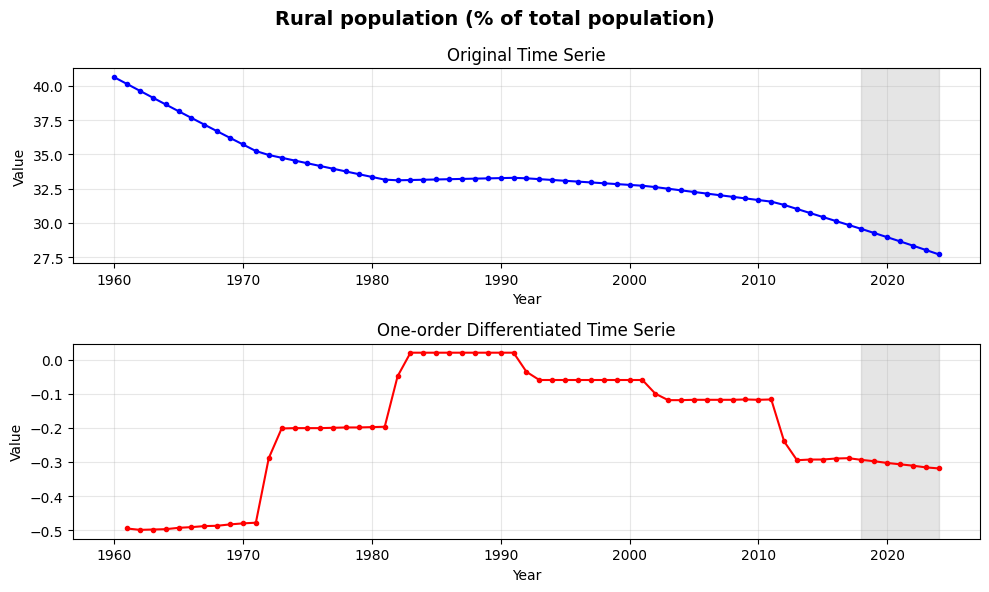

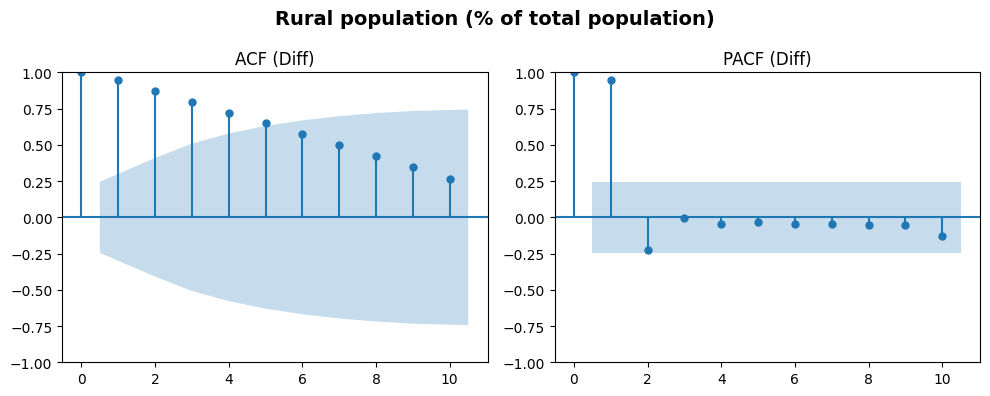


Indicator: Rural population growth (annual %)
ADF Statistic: -1.2740
p-value: 0.6410
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.6468, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year     Value      Diff
0  1961 -0.557139       NaN
1  1962 -0.574190 -0.017051
2  1963 -0.534554  0.039637
3  1964 -0.455075  0.079479
4  1965 -0.441649  0.013425


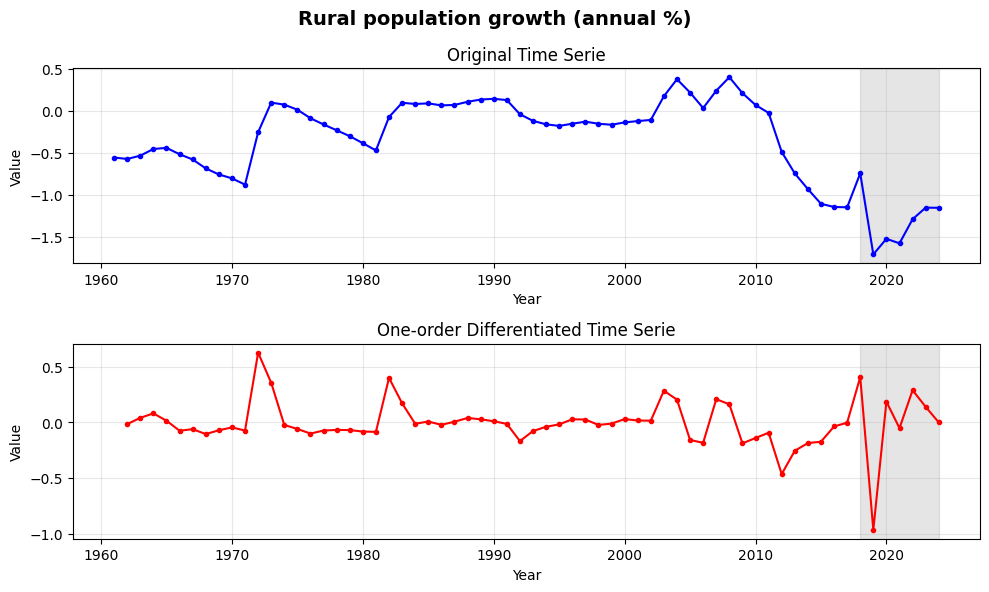

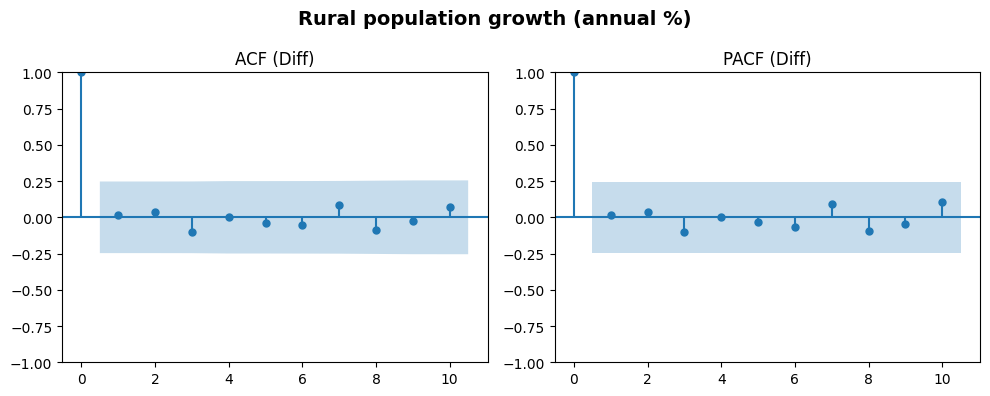


Indicator: Rural population
ADF Statistic: -0.0489
p-value: 0.9543
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -1.4383, p-value = 0.5638
Differenziazione n.2: ADF = -7.4670, p-value = 0.0000
Serie stazionaria dopo 2 differenziazioni.
   Year       Value     Diff
0  1960  20400656.0      NaN
1  1961  20287312.0      NaN
2  1962  20171158.0  -2810.0
3  1963  20063620.0   8616.0
4  1964  19972523.0  16441.0


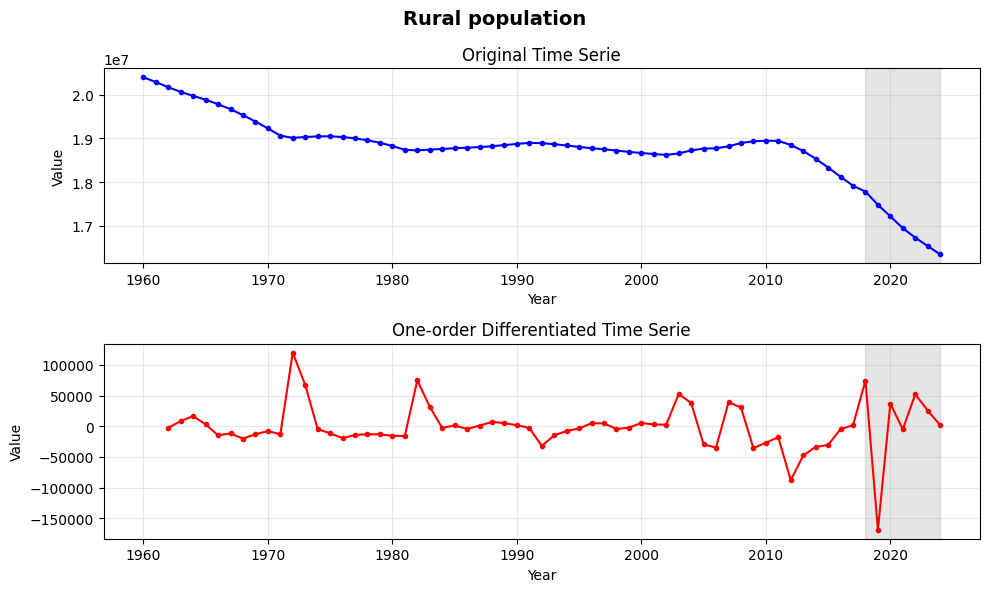

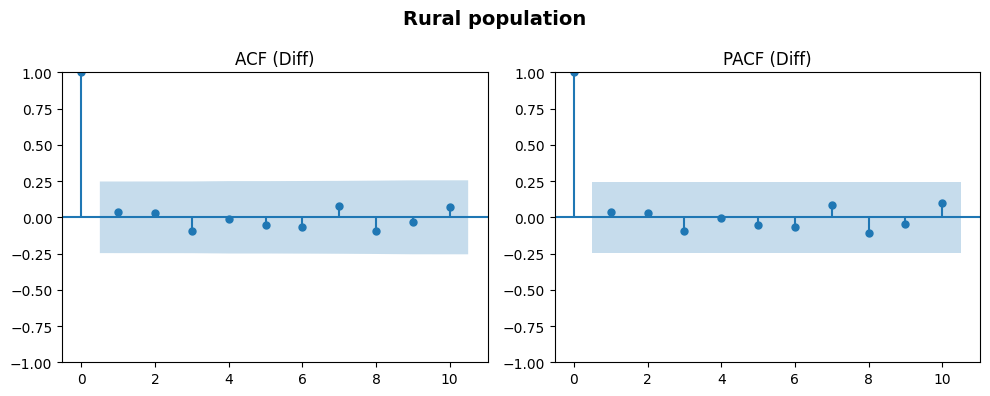


Indicator: Rural population living in areas where elevation is below 5 meters (% of total population)
Serie di Rural population living in areas where elevation is below 5 meters (% of total population) troppo corta: 3 osservazioni.

Indicator: Access to electricity, rural (% of rural population)
Errore nel test ADF per Access to electricity, rural (% of rural population): Invalid input, x is constant

Indicator: Employment in agriculture (% of total employment)
ADF Statistic: -5.5667
p-value: 0.0000
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


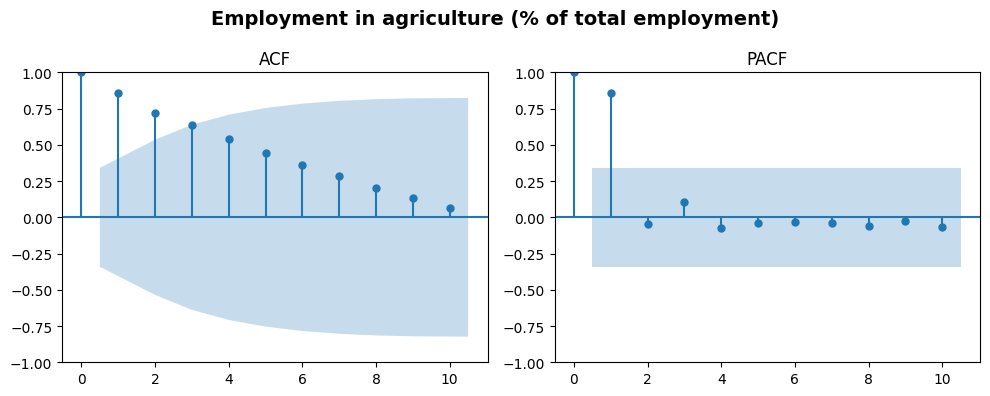


Indicator: Employment in agriculture, male (% of male employment)
ADF Statistic: -4.0417
p-value: 0.0012
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


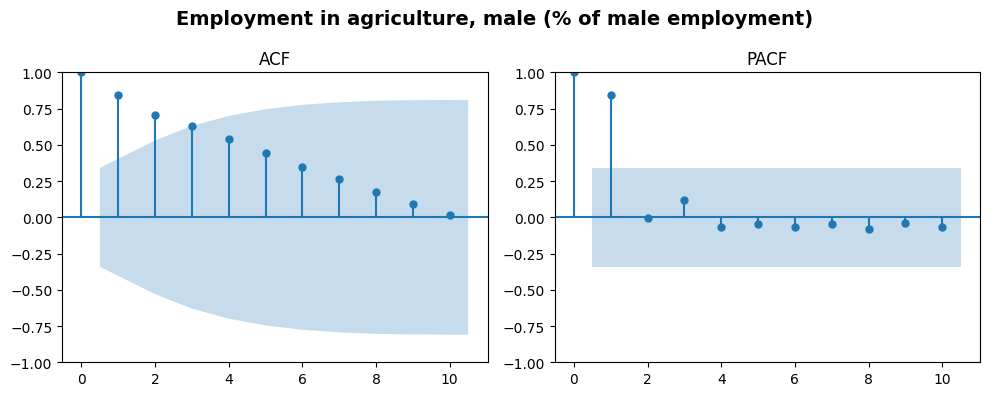


Indicator: Employment in agriculture, female (% of female employment)
ADF Statistic: -3.9776
p-value: 0.0015
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


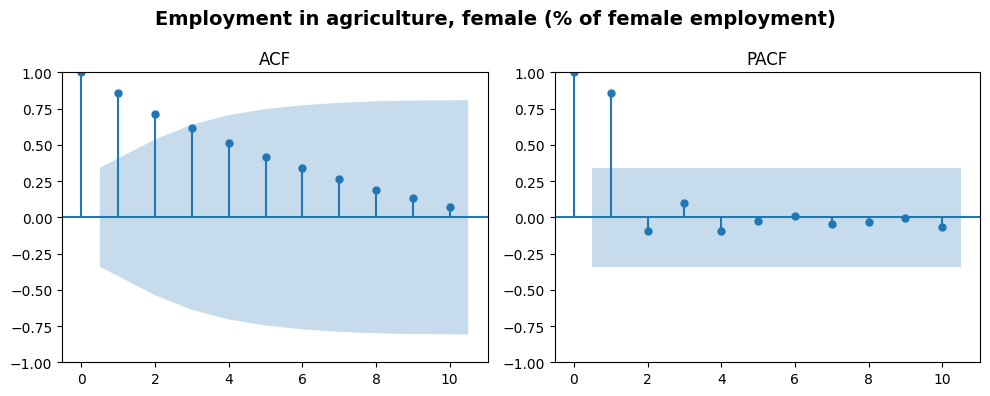


Indicator: Surface area (sq. km)
ADF Statistic: -0.7465
p-value: 0.8343
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.7463, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year     Value  Diff
0  1961  301340.0   NaN
1  1962  301340.0   0.0
2  1963  301340.0   0.0
3  1964  301340.0   0.0
4  1965  301340.0   0.0


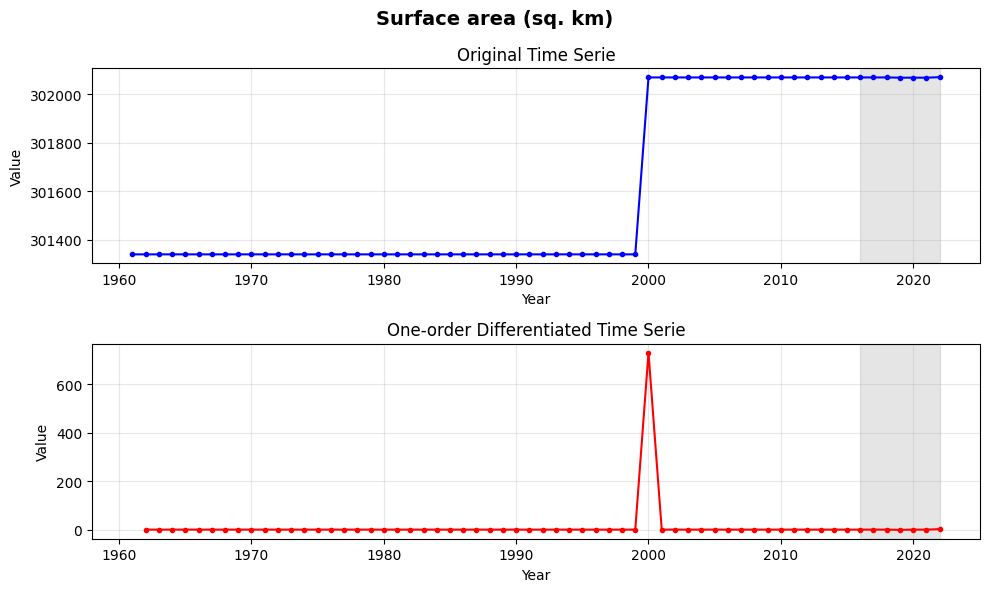

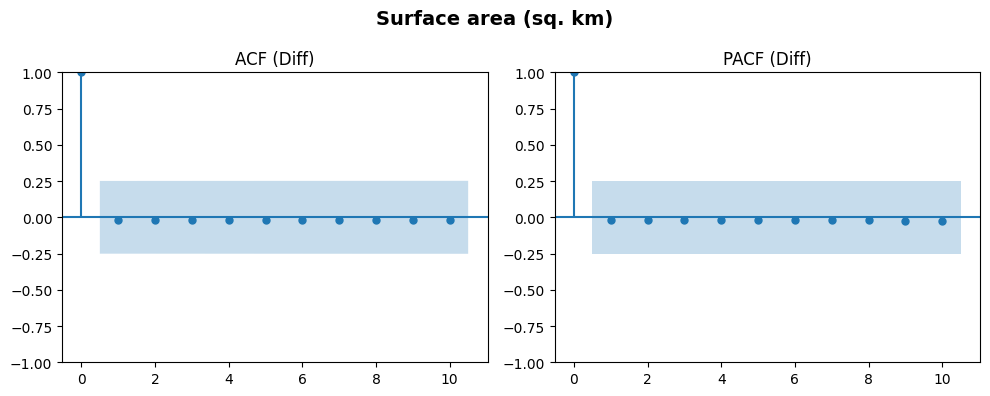


Indicator: Land area (sq. km)
ADF Statistic: -0.7467
p-value: 0.8343
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.7463, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year     Value  Diff
0  1961  294110.0   NaN
1  1962  294110.0   0.0
2  1963  294110.0   0.0
3  1964  294110.0   0.0
4  1965  294110.0   0.0


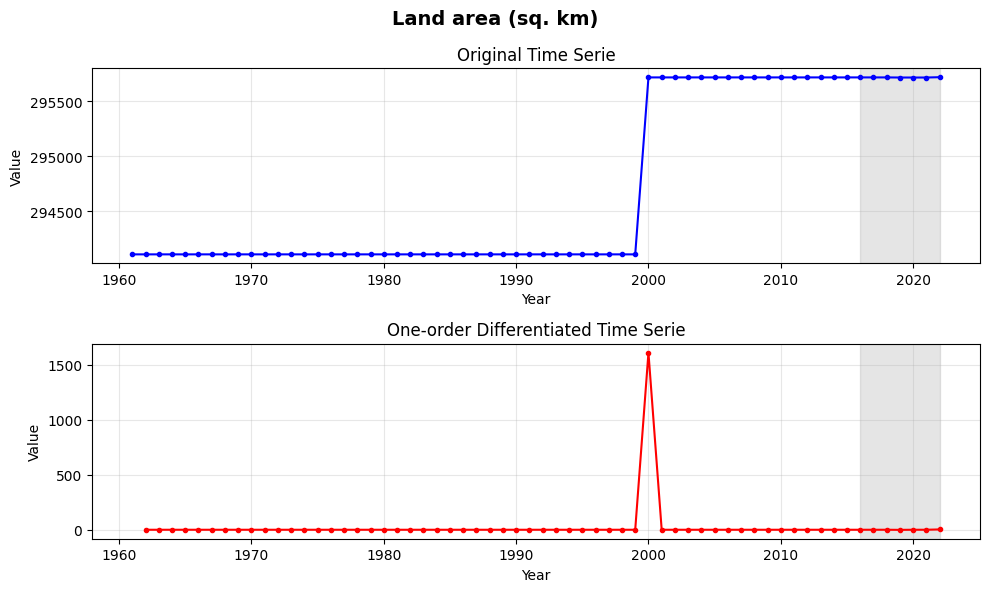

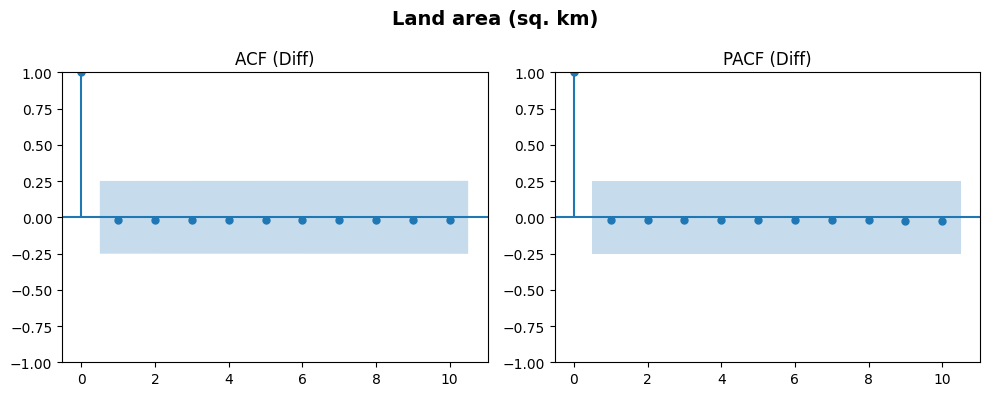


Indicator: Rural land area (sq. km)
Serie di Rural land area (sq. km) troppo corta: 3 osservazioni.

Indicator: Rural land area where elevation is below 5 meters (% of total land area)
Serie di Rural land area where elevation is below 5 meters (% of total land area) troppo corta: 3 osservazioni.

Indicator: Rural land area where elevation is below 5 meters (sq. km)
Serie di Rural land area where elevation is below 5 meters (sq. km) troppo corta: 3 osservazioni.

Indicator: Forest area (% of land area)
ADF Statistic: -21.2138
p-value: 0.0000
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


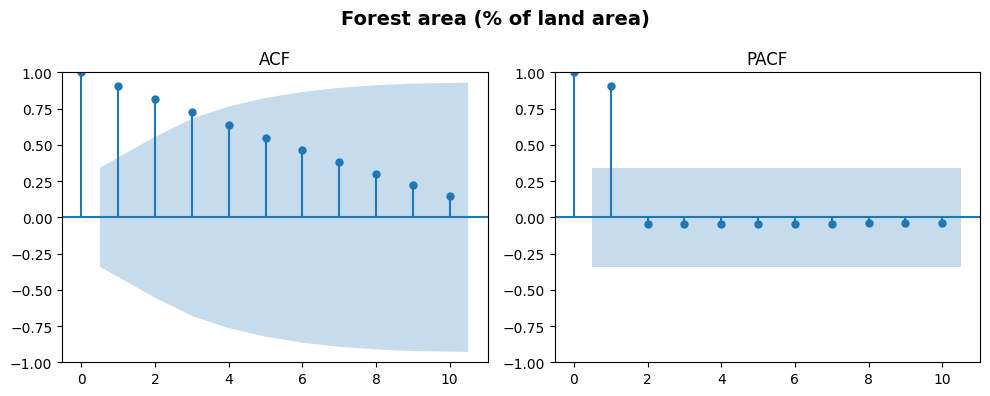


Indicator: Forest area (sq. km)
ADF Statistic: -2.6695
p-value: 0.0795
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -0.9289, p-value = 0.7783
Differenziazione n.2: ADF = -5.6839, p-value = 0.0000
Serie stazionaria dopo 2 differenziazioni.
   Year    Value  Diff
0  1990  75897.5   NaN
1  1991  76677.0   NaN
2  1992  77456.5   0.0
3  1993  78236.0   0.0
4  1994  79015.5   0.0


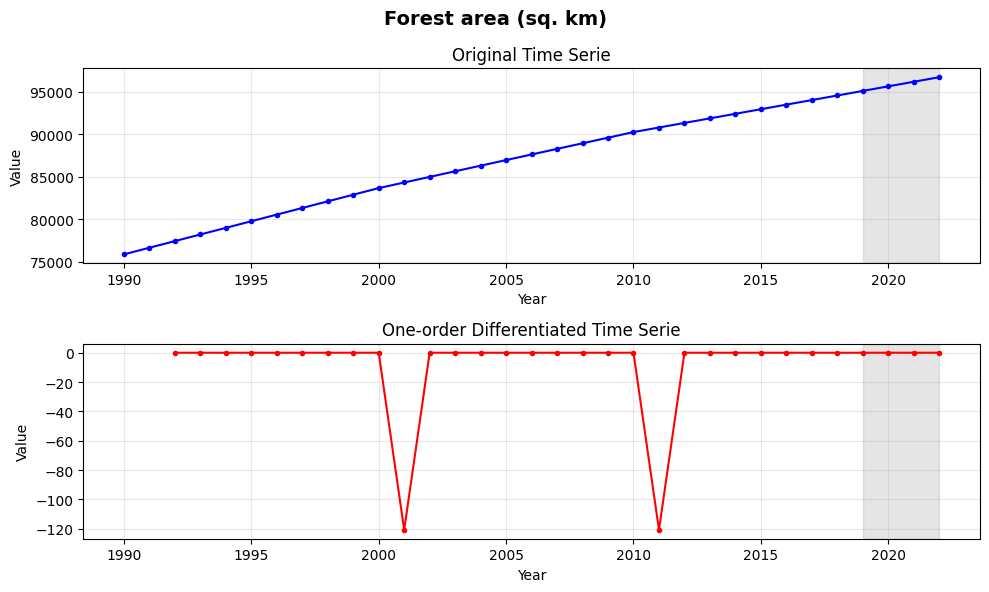

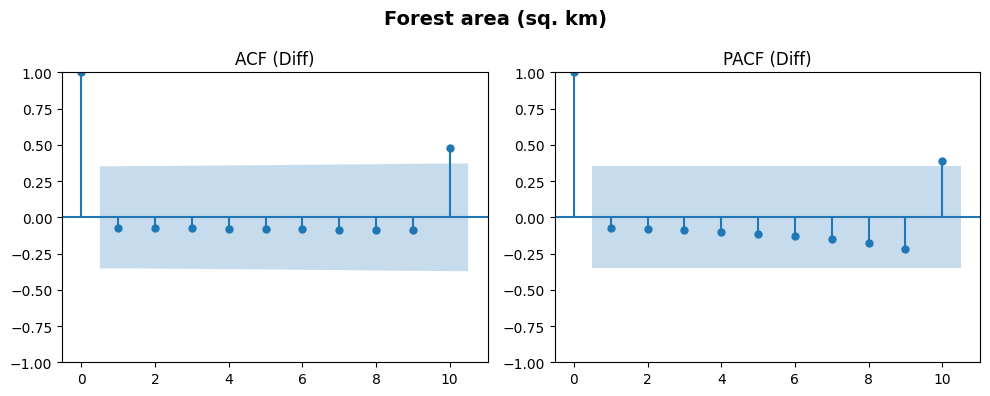


Indicator: Agricultural land (% of land area)
ADF Statistic: -1.2346
p-value: 0.6585
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -8.4019, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year      Value      Diff
0  1961  70.324028       NaN
1  1962  70.218626 -0.105403
2  1963  69.735813 -0.482813
3  1964  69.572609 -0.163204
4  1965  69.497807 -0.074802


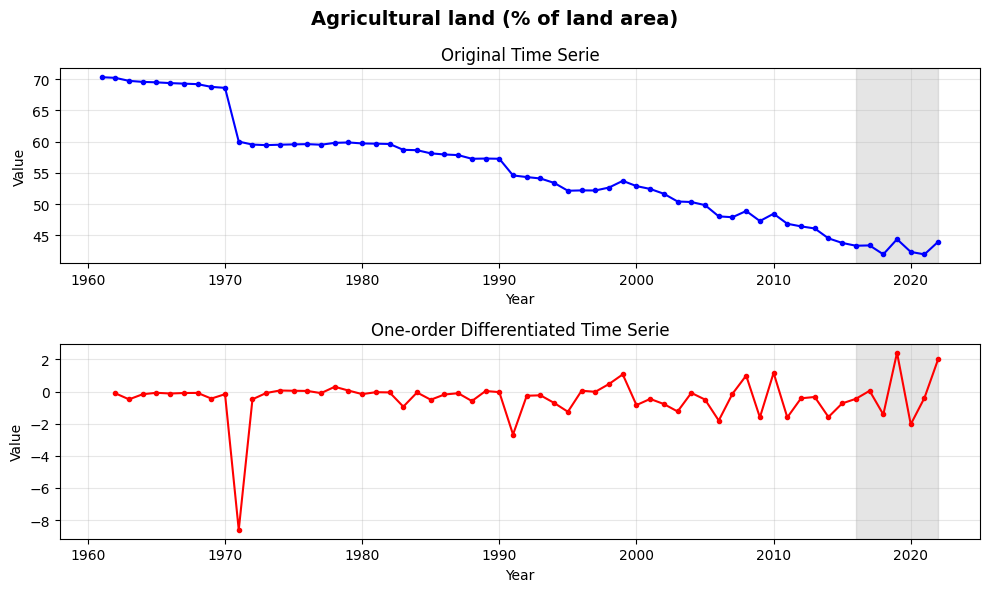

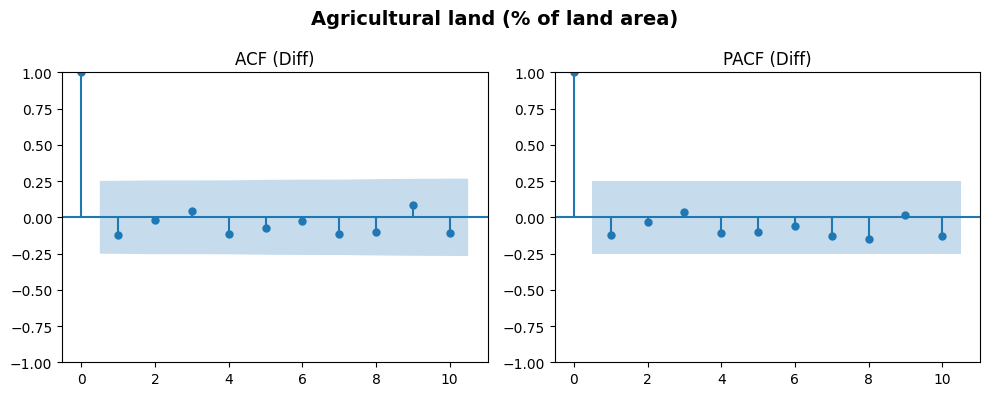


Indicator: Agricultural land (sq. km)
ADF Statistic: -0.8888
p-value: 0.7916
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -8.5663, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year     Value    Diff
0  1961  206830.0     NaN
1  1962  206520.0  -310.0
2  1963  205100.0 -1420.0
3  1964  204620.0  -480.0
4  1965  204400.0  -220.0


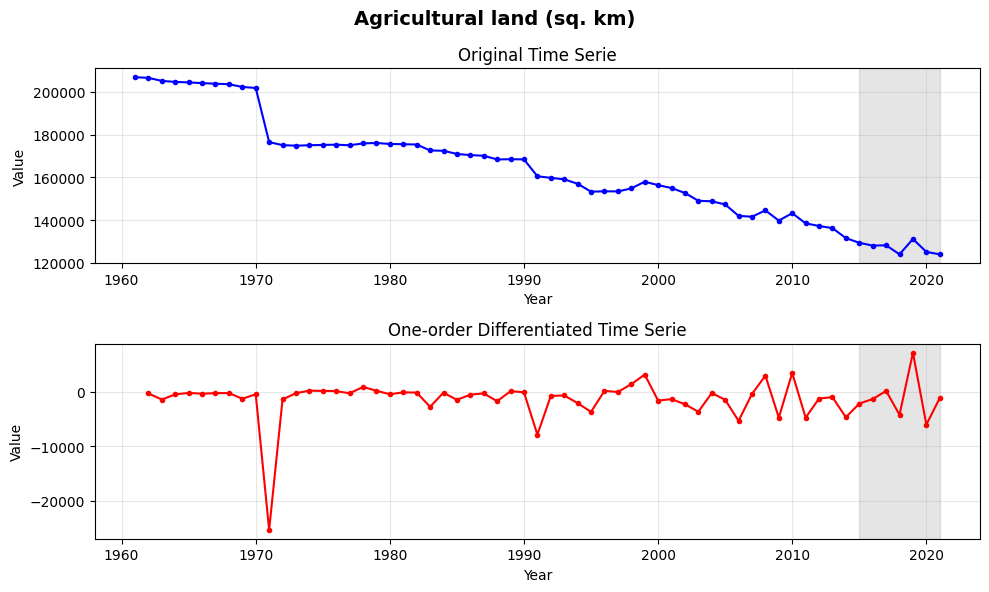

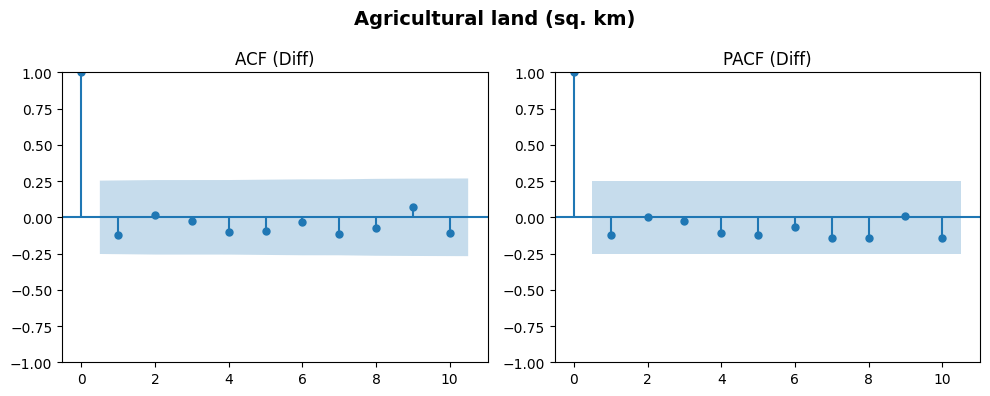


Indicator: Arable land (% of land area)
ADF Statistic: -2.0241
p-value: 0.2761
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.3582, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year      Value      Diff
0  1961  43.731937       NaN
1  1962  43.504131 -0.227806
2  1963  43.092720 -0.411411
3  1964  42.834314 -0.258407
4  1965  42.582707 -0.251607


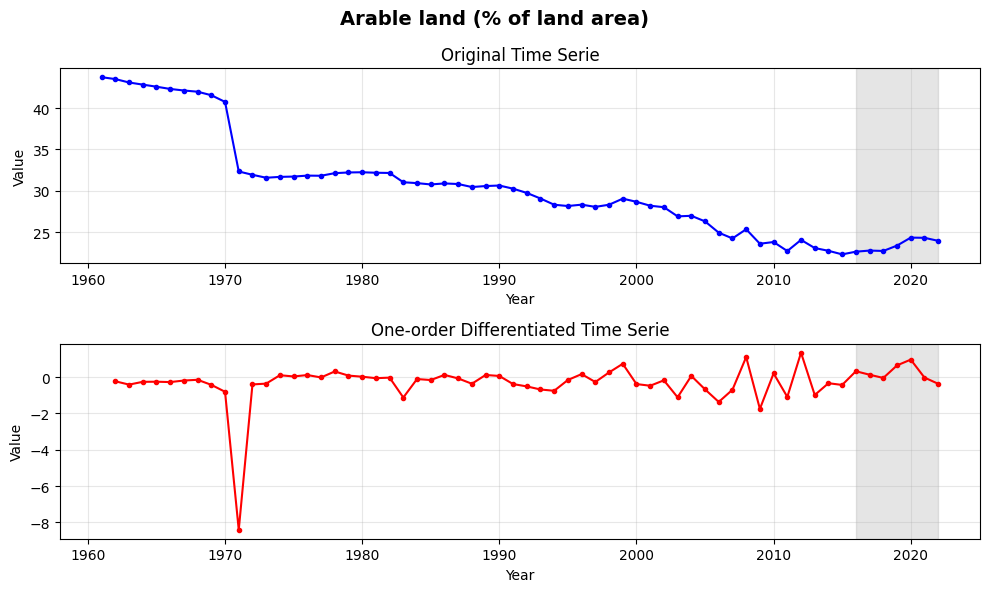

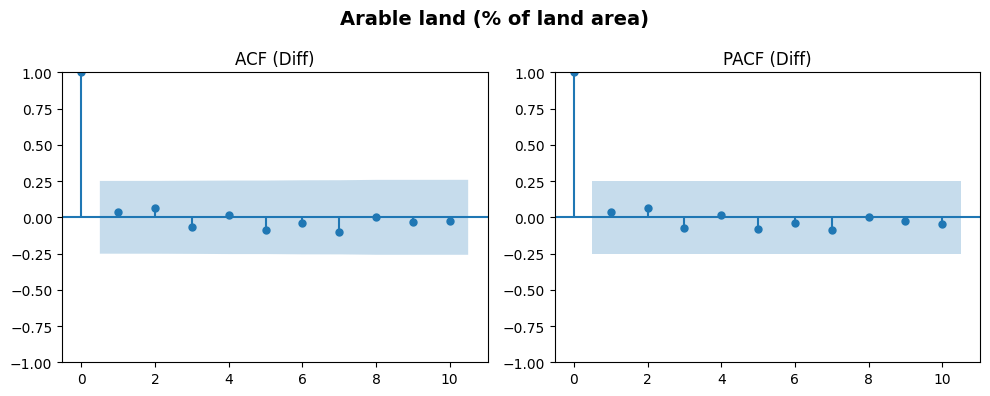


Indicator: Arable land (hectares per person)
ADF Statistic: -2.5940
p-value: 0.0942
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -4.4399, p-value = 0.0003
Serie stazionaria dopo 1 differenziazioni.
   Year     Value      Diff
0  1961  0.254510       NaN
1  1962  0.251477 -0.003033
2  1963  0.247288 -0.004189
3  1964  0.243791 -0.003497
4  1965  0.240327 -0.003464


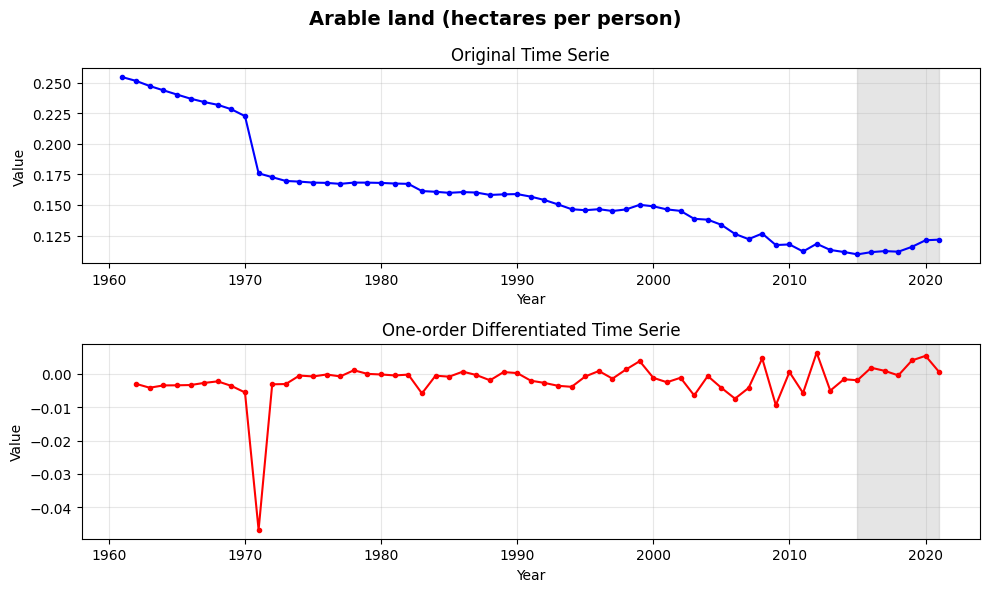

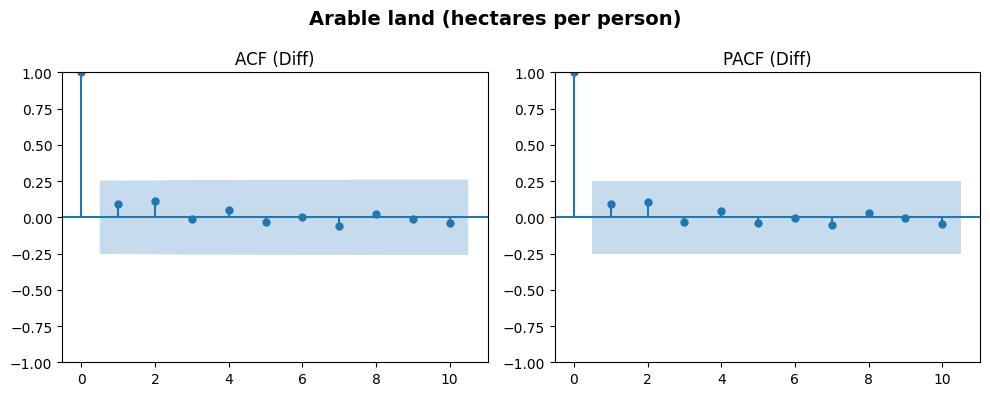


Indicator: Arable land (hectares)
ADF Statistic: -2.0418
p-value: 0.2686
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.2816, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year       Value      Diff
0  1961  12862000.0       NaN
1  1962  12795000.0  -67000.0
2  1963  12674000.0 -121000.0
3  1964  12598000.0  -76000.0
4  1965  12524000.0  -74000.0


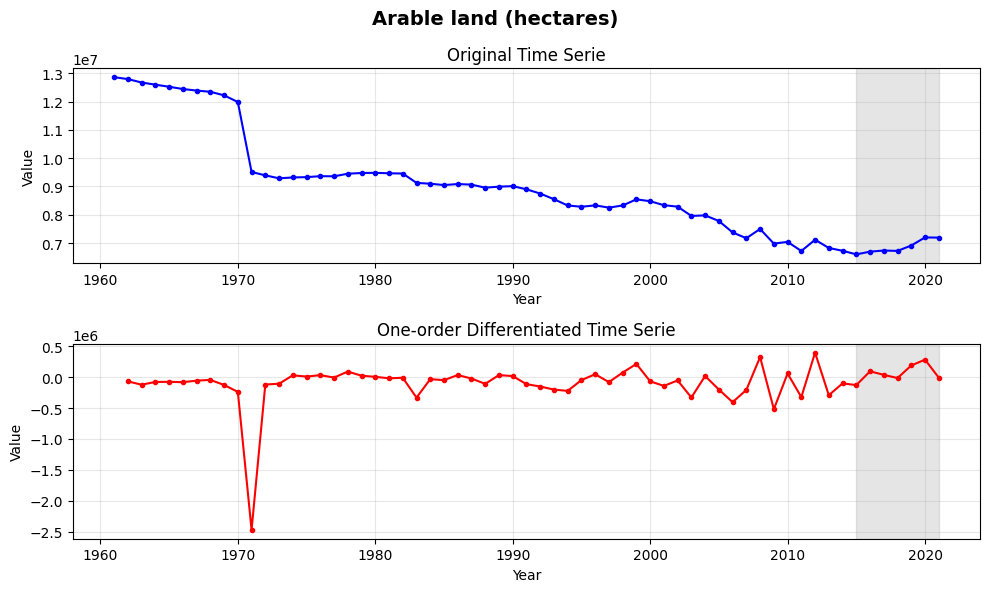

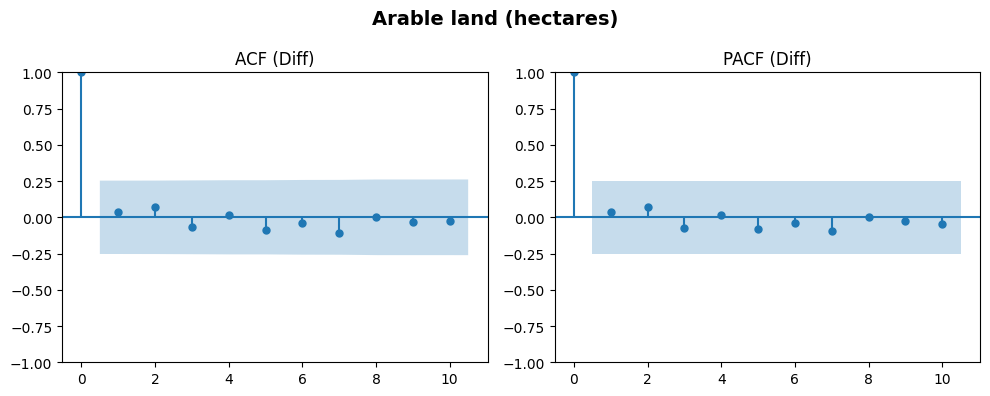


Indicator: Land under cereal production (hectares)
ADF Statistic: -1.3744
p-value: 0.5945
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -10.8306, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year      Value      Diff
0  1961  6387203.0       NaN
1  1962  6485855.0   98652.0
2  1963  6299467.0 -186388.0
3  1964  6244904.0  -54563.0
4  1965  6056518.0 -188386.0


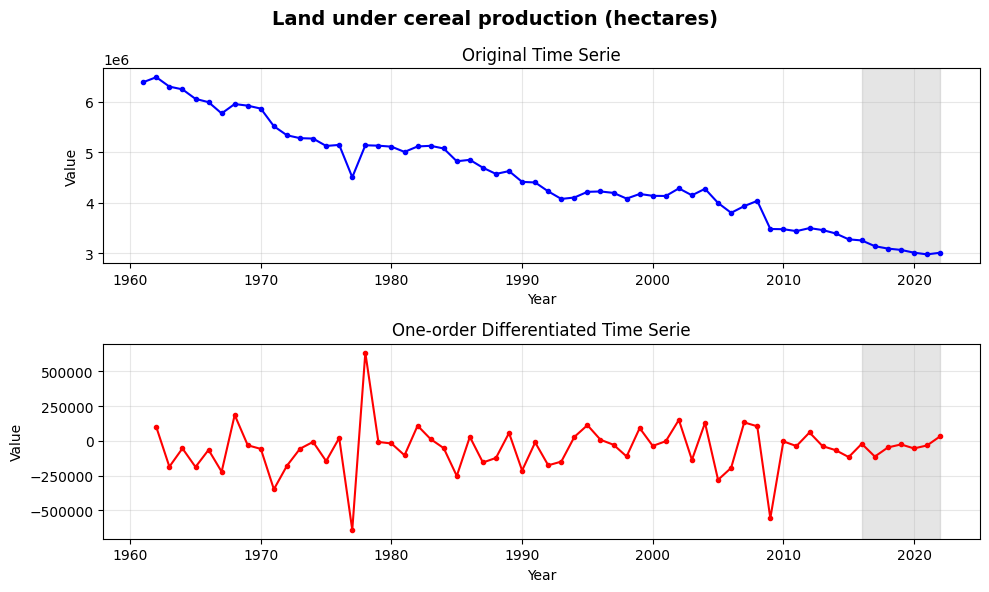

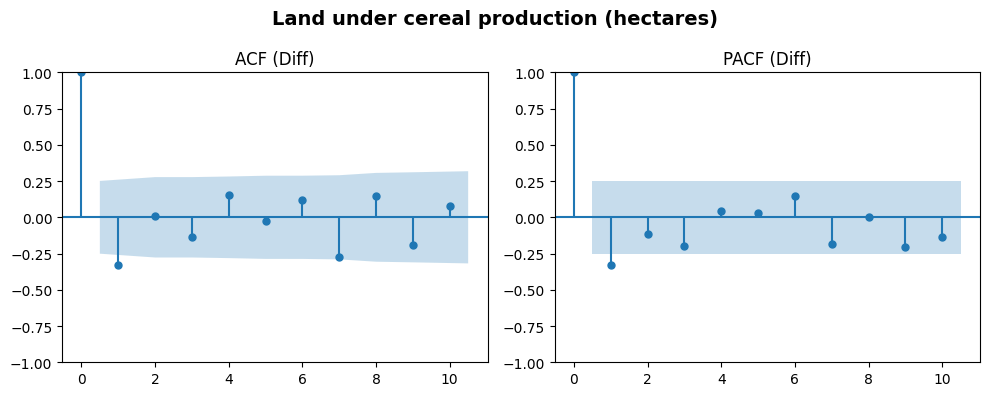


Indicator: Permanent cropland (% of land area)
ADF Statistic: -0.7408
p-value: 0.8359
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -5.0807, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year     Value      Diff
0  1961  9.336643       NaN
1  1962  9.435245  0.098603
2  1963  9.319642 -0.115603
3  1964  9.438645  0.119003
4  1965  9.445446  0.006800


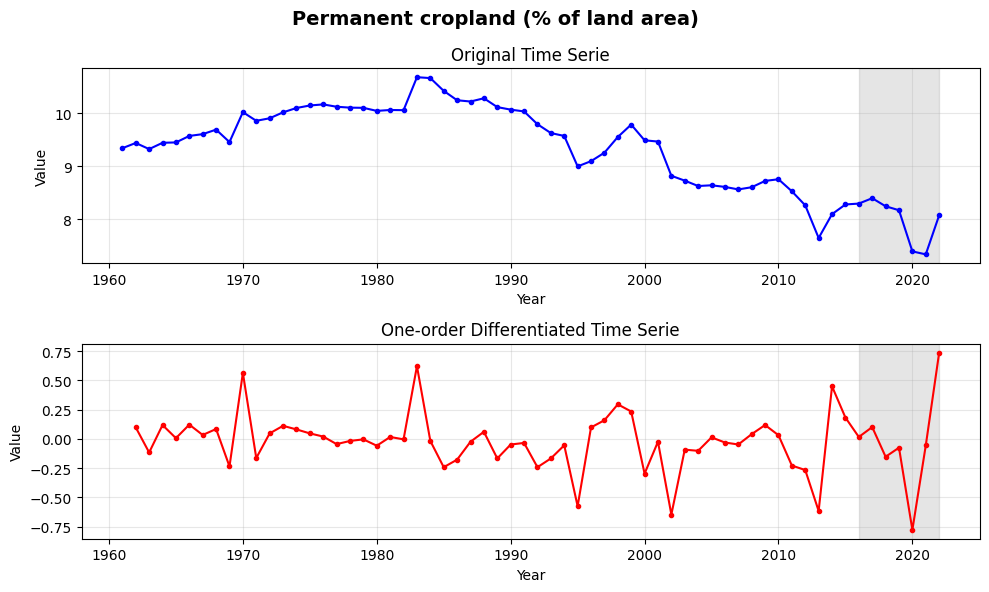

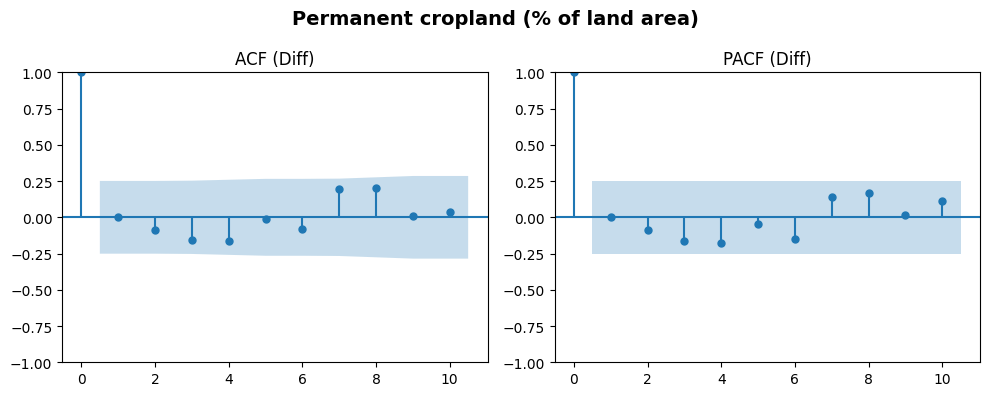


Indicator: Average precipitation in depth (mm per year)
Errore nel test ADF per Average precipitation in depth (mm per year): Invalid input, x is constant

Indicator: Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)
ADF Statistic: -2.0918
p-value: 0.2478
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -9.3390, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year      Value      Diff
0  1970  61.538462       NaN
1  1971  60.354920 -1.183542
2  1972  59.201104 -1.153816
3  1973  58.075908 -1.125196
4  1974  56.978280 -1.097628


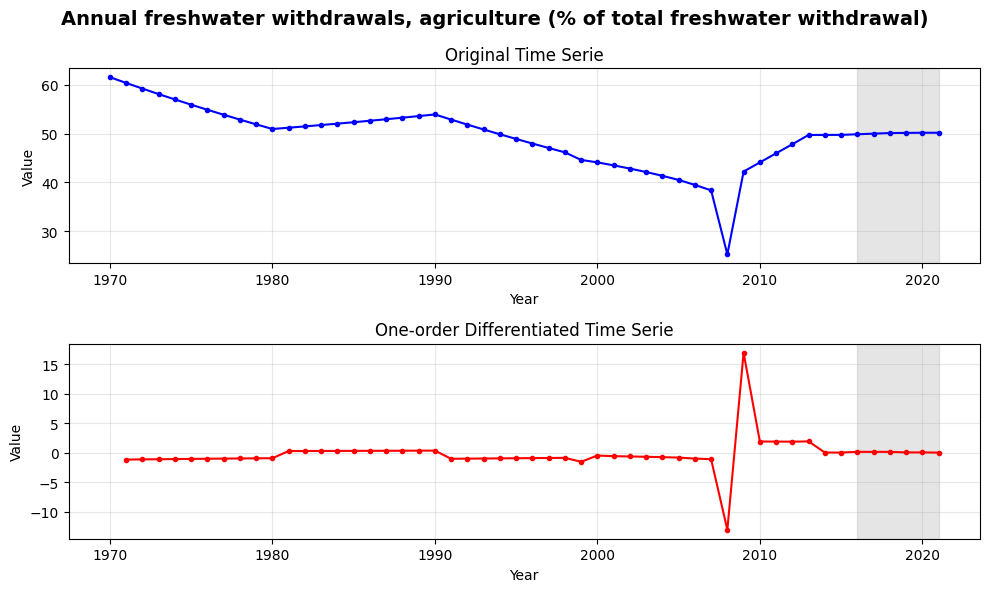

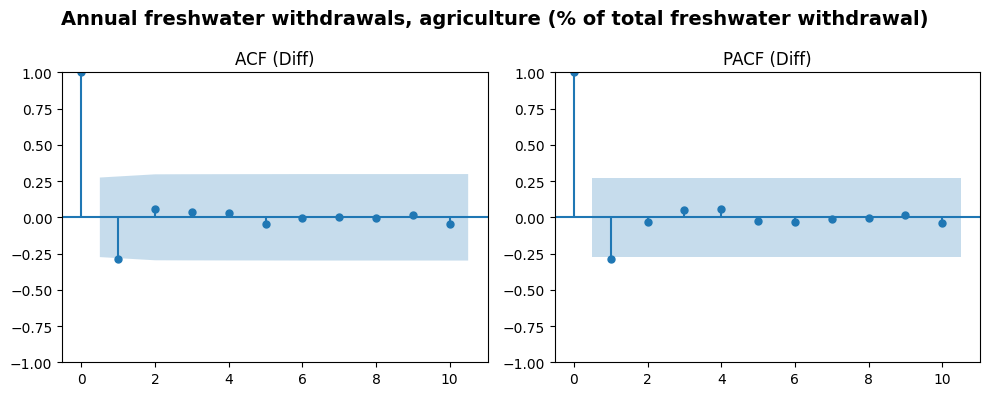


Indicator: Agricultural irrigated land (% of total agricultural land)
Serie di Agricultural irrigated land (% of total agricultural land) troppo corta: 7 osservazioni.

Indicator: Fertilizer consumption (kilograms per hectare of arable land)
ADF Statistic: -2.4464
p-value: 0.1291
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -1.1675, p-value = 0.6874
Differenziazione n.2: ADF = -5.6761, p-value = 0.0000
Serie stazionaria dopo 2 differenziazioni.
   Year      Value      Diff
0  1961  67.795055       NaN
1  1962  69.362485       NaN
2  1963  68.764636 -2.165279
3  1964  74.639625  6.472838
4  1965  86.395481  5.880866


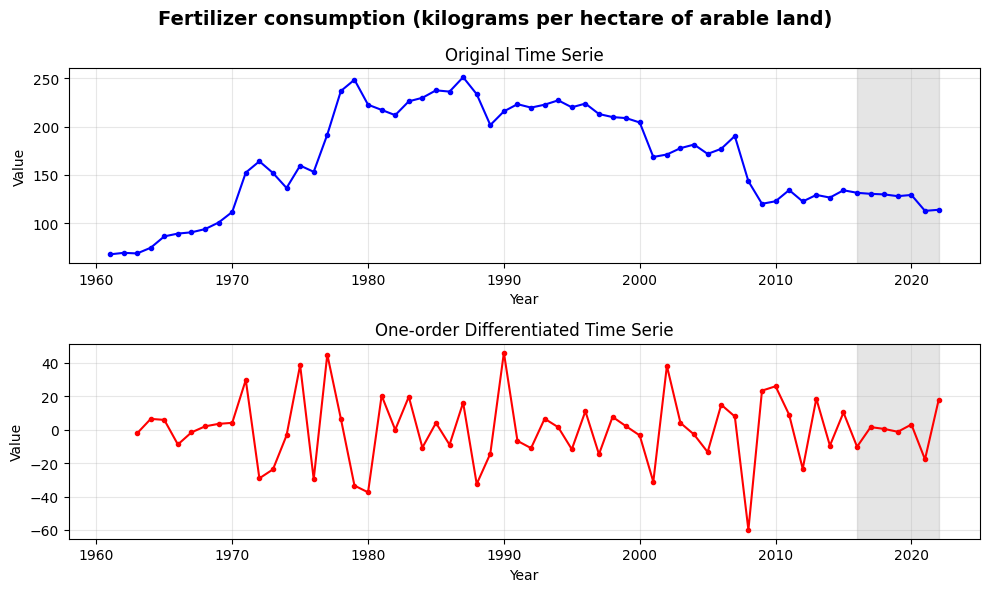

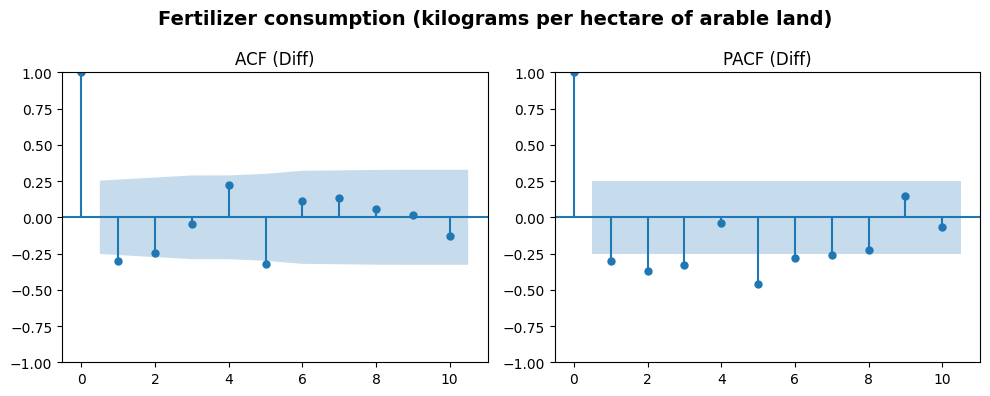


Indicator: Fertilizer consumption (% of fertilizer production)
ADF Statistic: -1.5620
p-value: 0.5027
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.5112, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year      Value      Diff
0  1961  72.707716       NaN
1  1962  70.071359 -2.636357
2  1963  63.883735 -6.187623
3  1964  64.593354  0.709619
4  1965  68.034311  3.440957


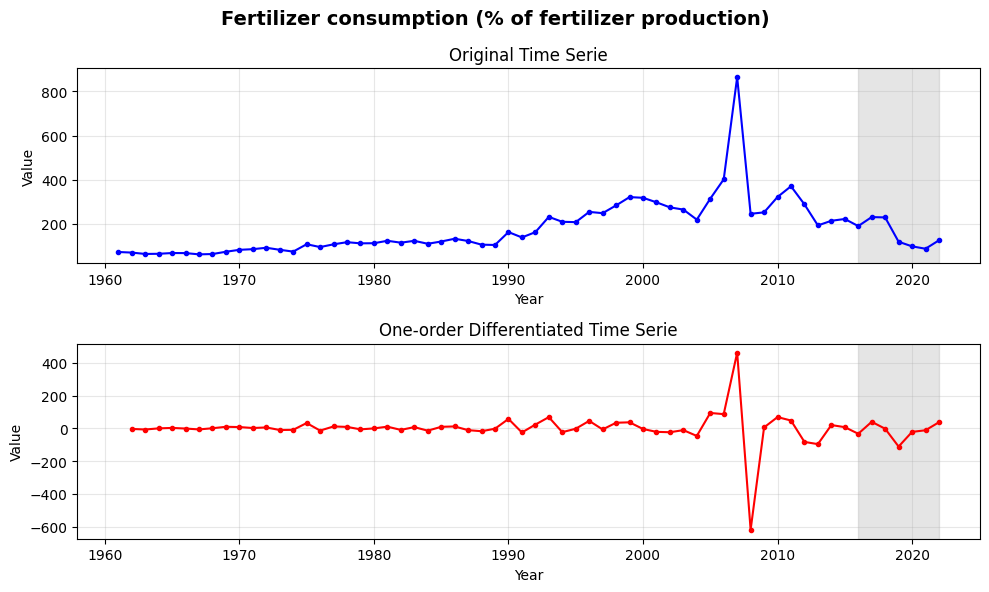

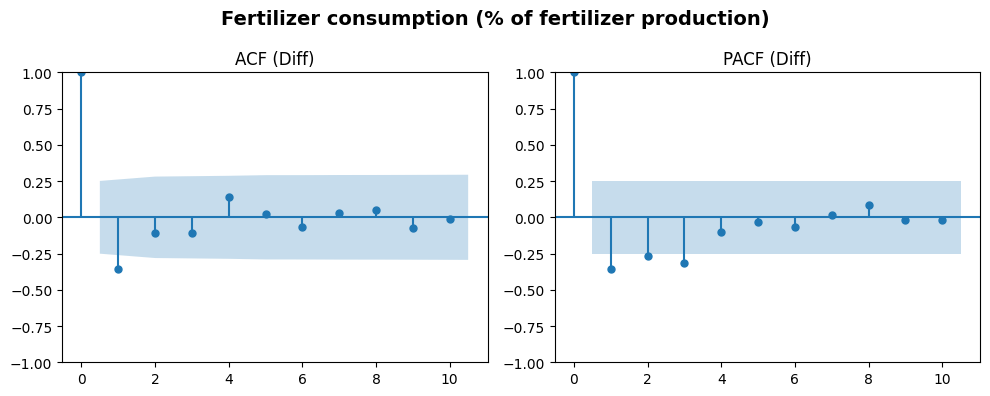


Indicator: Livestock production index (2014-2016 = 100)
ADF Statistic: -2.7642
p-value: 0.0636
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -4.0456, p-value = 0.0012
Serie stazionaria dopo 1 differenziazioni.
   Year  Value  Diff
0  1961  70.91   NaN
1  1962  72.59  1.68
2  1963  65.95 -6.64
3  1964  69.57  3.62
4  1965  72.80  3.23


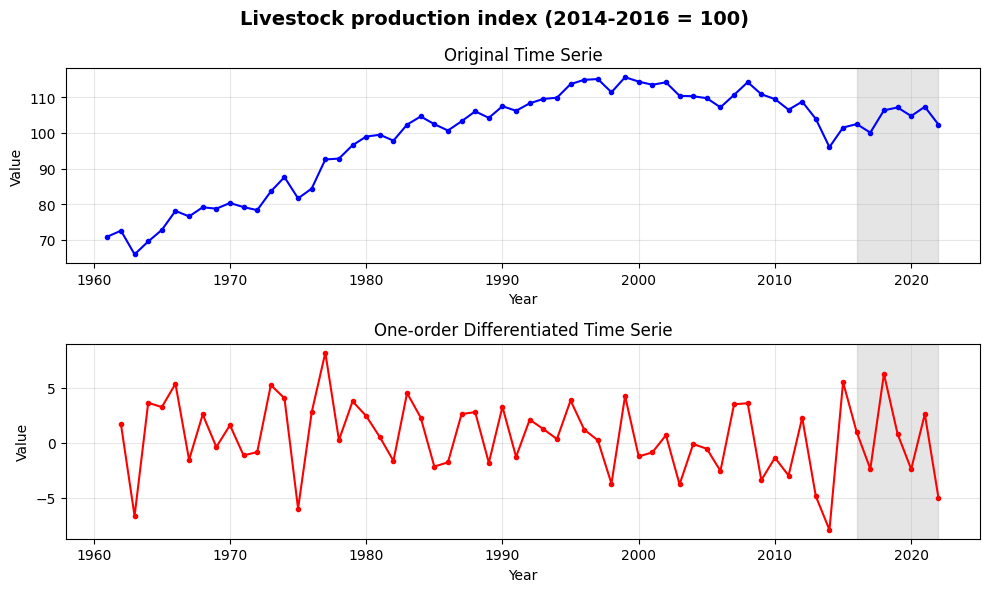

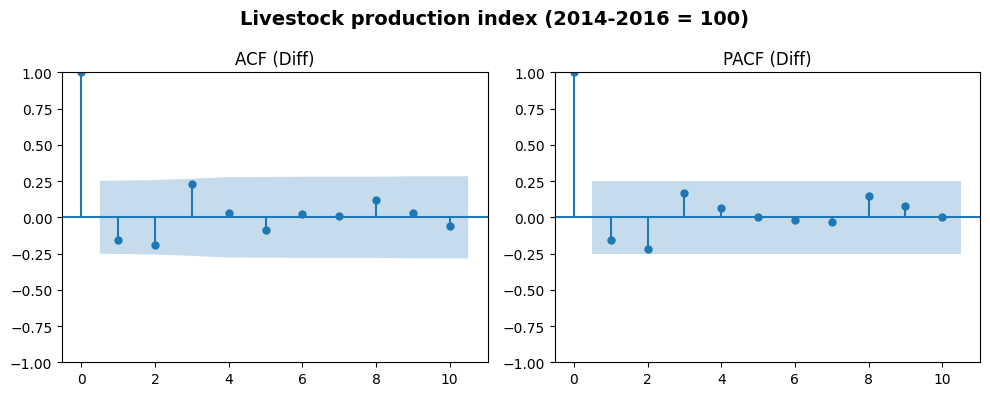


Indicator: Food production index (2014-2016 = 100)
ADF Statistic: -2.4827
p-value: 0.1198
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -6.4485, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year  Value  Diff
0  1961  85.93   NaN
1  1962  86.90  0.97
2  1963  86.37 -0.53
3  1964  90.28  3.91
4  1965  92.75  2.47


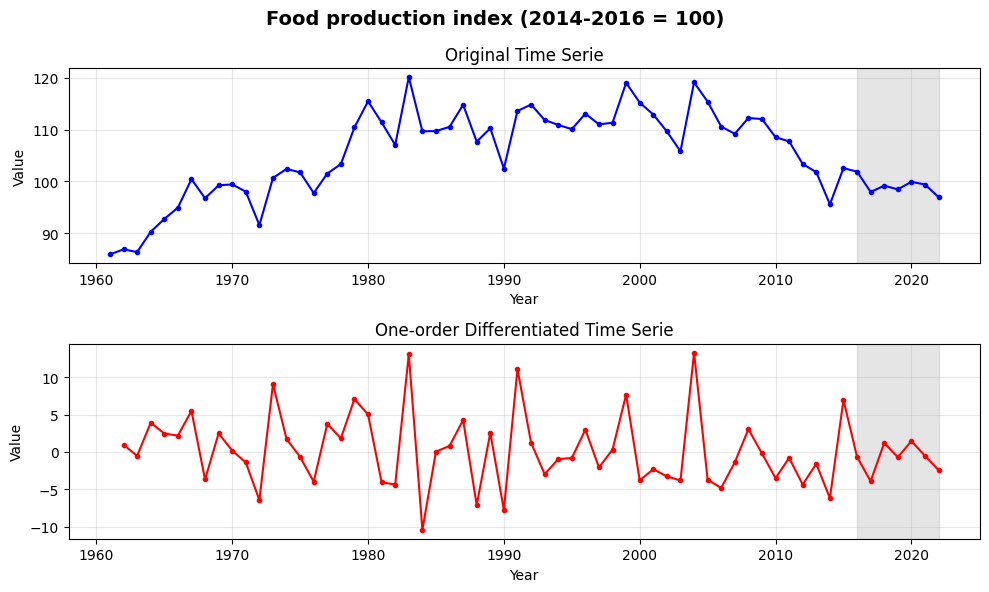

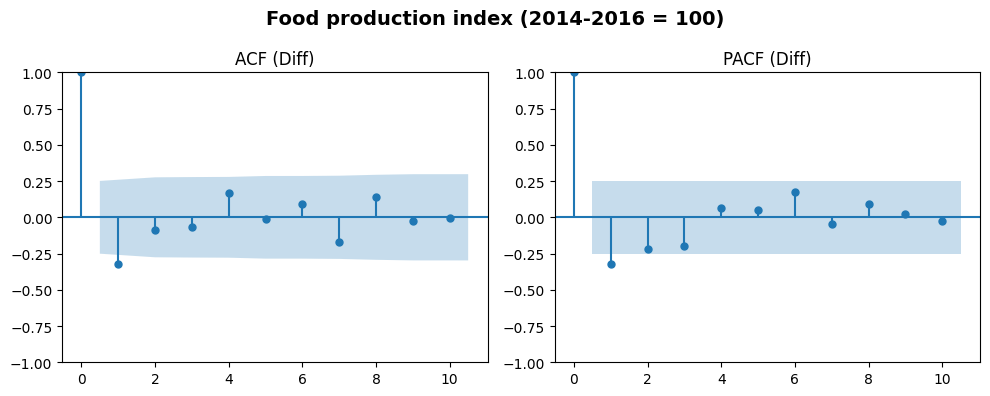


Indicator: Crop production index (2014-2016 = 100)
ADF Statistic: -1.2687
p-value: 0.6434
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -7.2662, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year   Value  Diff
0  1961   93.68   NaN
1  1962   94.43  0.75
2  1963   97.19  2.76
3  1964  101.31  4.12
4  1965  103.32  2.01


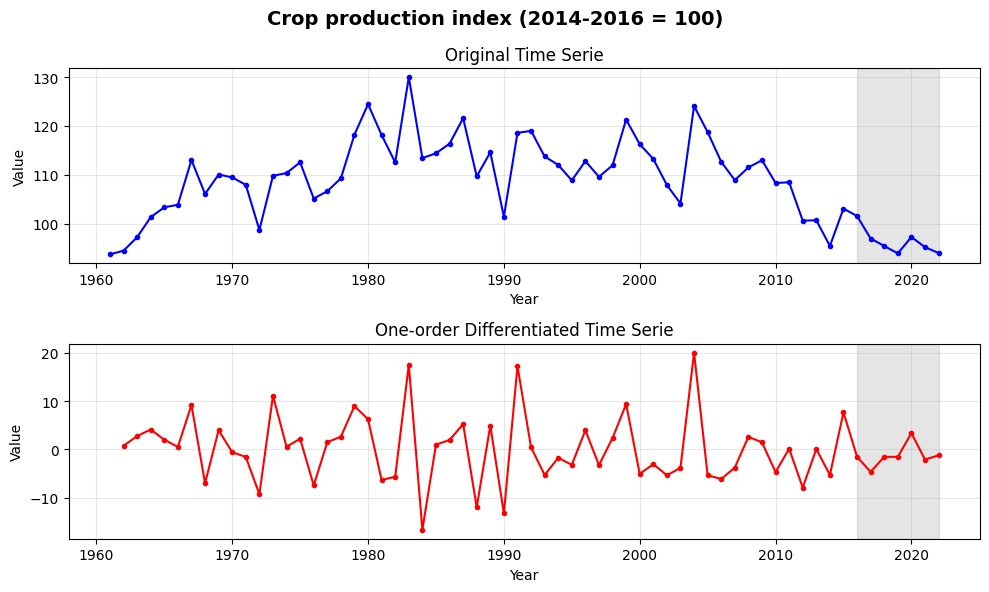

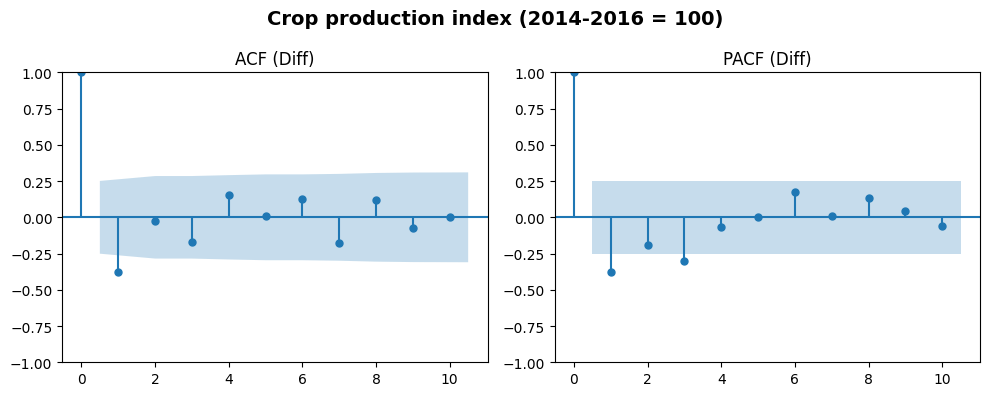


Indicator: Cereal production (metric tons)
ADF Statistic: -1.7578
p-value: 0.4016
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -8.3101, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year       Value       Diff
0  1961  13933400.0        NaN
1  1962  14433210.0   499810.0
2  1963  13324660.0 -1108550.0
3  1964  14007520.0   682860.0
4  1965  14531270.0   523750.0


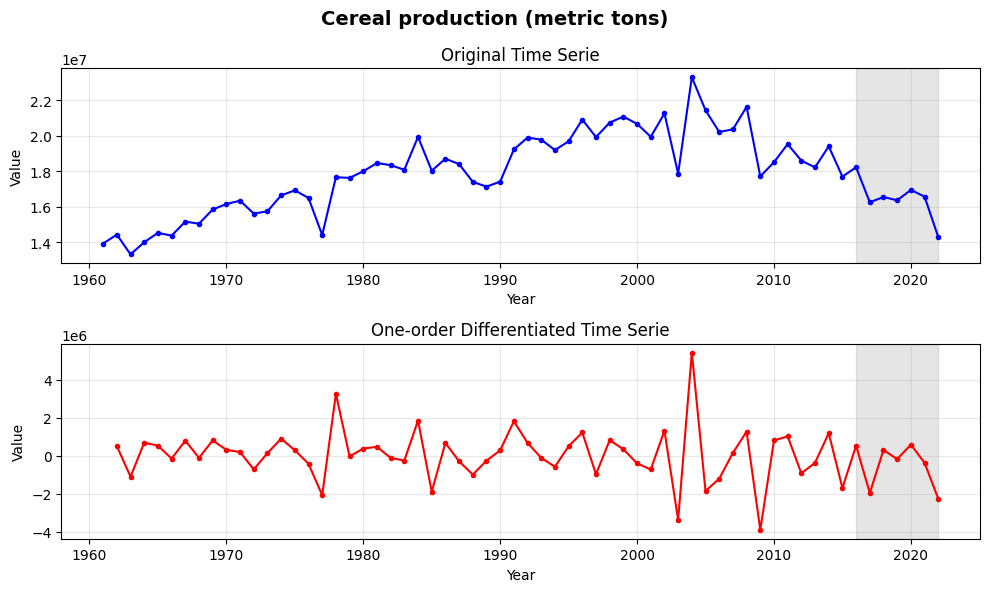

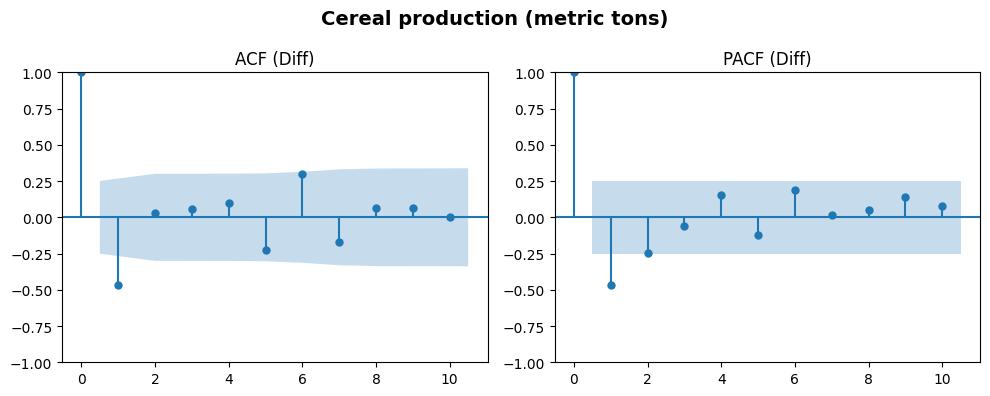


Indicator: Cereal yield (kg per hectare)
ADF Statistic: -1.9385
p-value: 0.3142
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -10.5822, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year   Value   Diff
0  1961  2181.5    NaN
1  1962  2225.3   43.8
2  1963  2115.2 -110.1
3  1964  2243.0  127.8
4  1965  2399.3  156.3


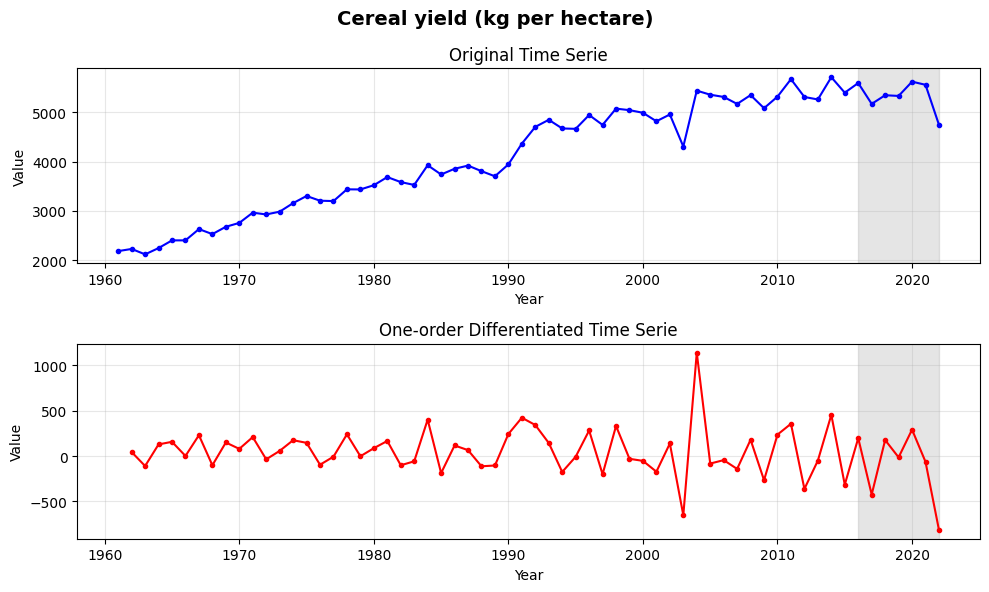

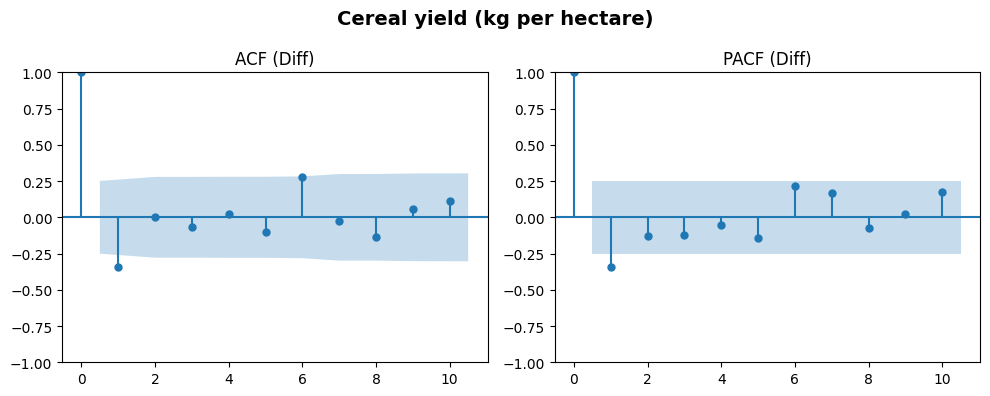


Indicator: Agriculture, forestry, and fishing, value added (% of GDP)
ADF Statistic: -2.0048
p-value: 0.2845
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -2.6704, p-value = 0.0793
Differenziazione n.2: ADF = -5.2062, p-value = 0.0000
Serie stazionaria dopo 2 differenziazioni.
   Year     Value      Diff
0  1990  3.178633       NaN
1  1991  3.235386       NaN
2  1992  3.114250 -0.177889
3  1993  2.995048  0.001933
4  1994  2.988089  0.112244


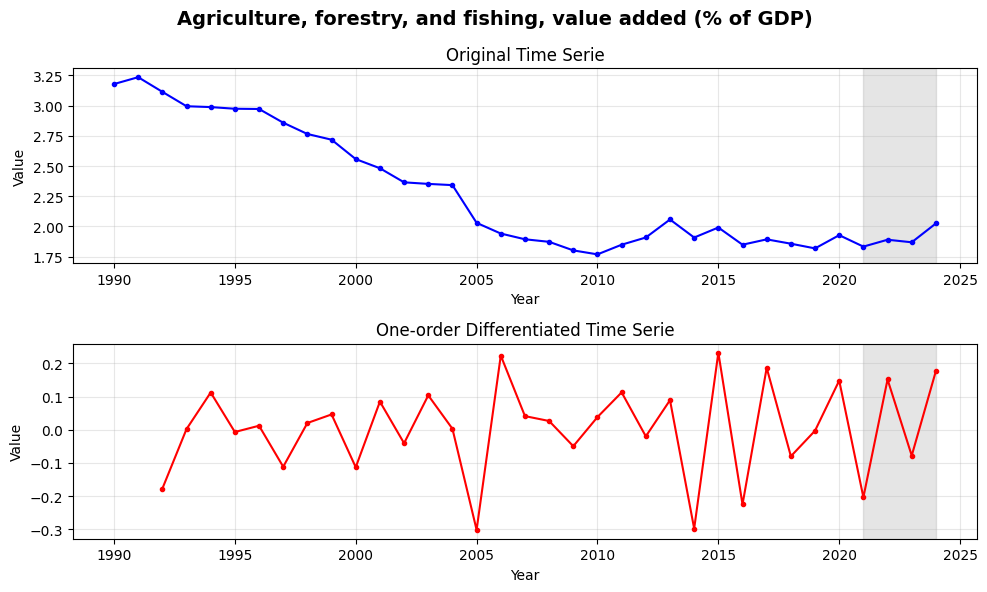

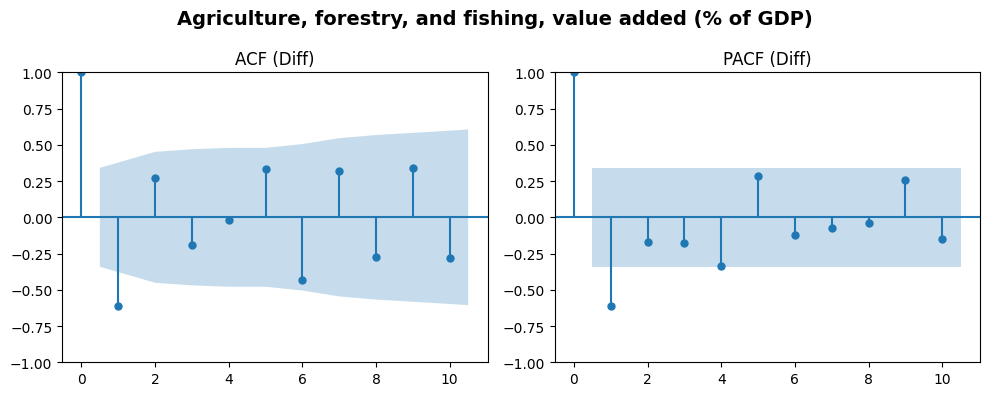


Indicator: Agriculture, forestry, and fishing, value added (current US$)
ADF Statistic: -2.1025
p-value: 0.2435
Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:
Differenziazione n.1: ADF = -5.3026, p-value = 0.0000
Serie stazionaria dopo 1 differenziazioni.
   Year         Value          Diff
0  1990  3.763327e+10           NaN
1  1991  4.041296e+10  2.779693e+09
2  1992  4.120790e+10  7.949339e+08
3  1993  3.196952e+10 -9.238378e+09
4  1994  3.292128e+10  9.517599e+08


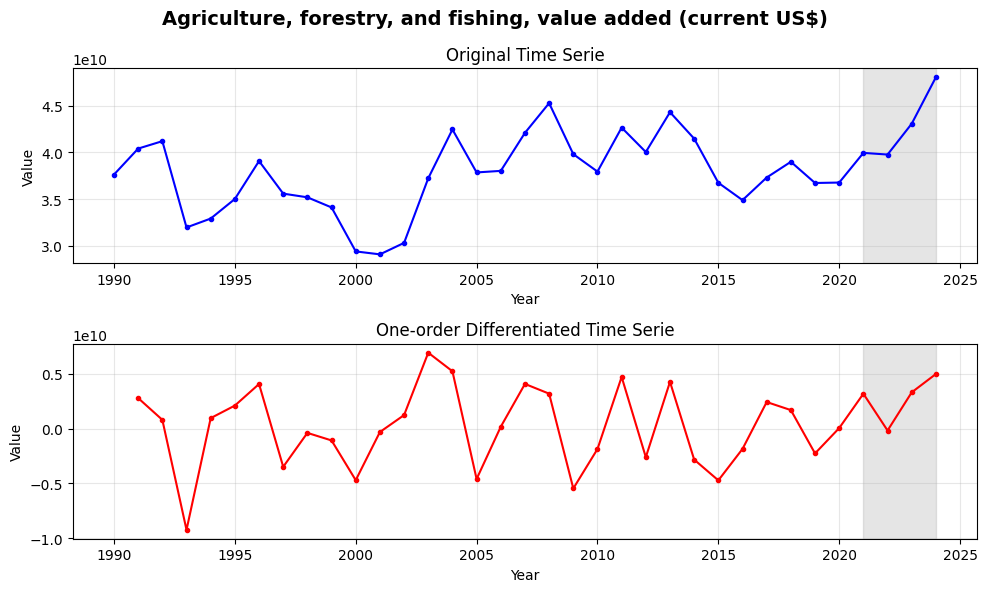

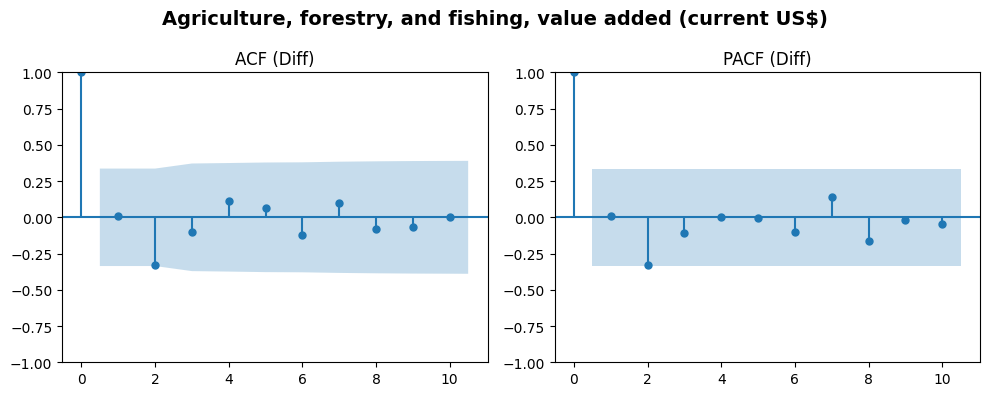


Indicator: Agricultural raw materials exports (% of merchandise exports)
ADF Statistic: -2.9249
p-value: 0.0425
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


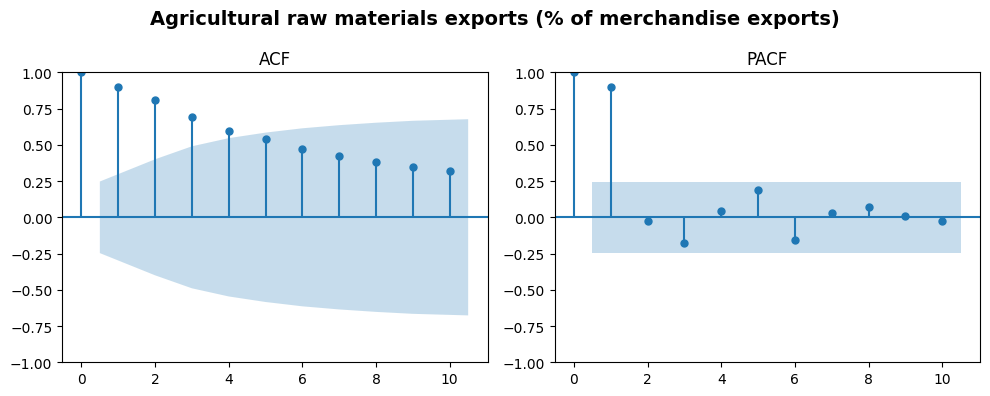


Indicator: Agricultural raw materials imports (% of merchandise imports)
ADF Statistic: -4.4610
p-value: 0.0002
Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:


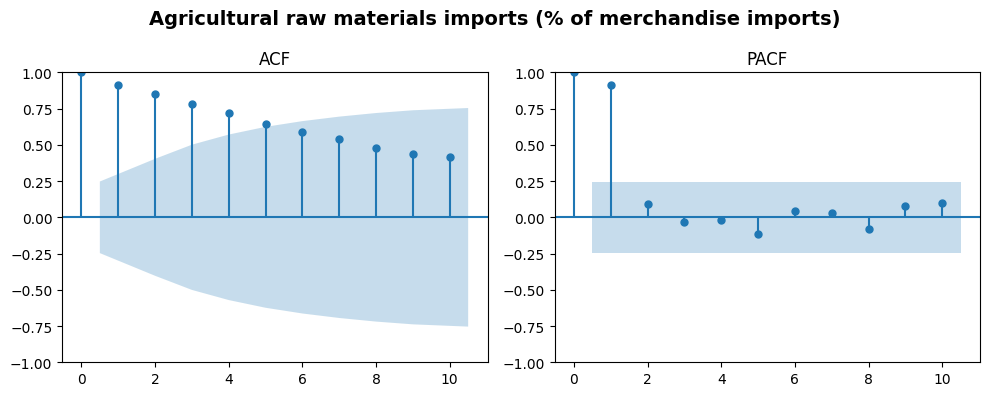

In [4]:
indicators = df["Indicator Name"].unique()

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )

    if df_temp.empty:
        print("Nessun dato disponibile, salto.")
        continue
    
    if len(df_temp) < 20:
        print(f"Serie di {indicator} troppo corta: {len(df_temp)} osservazioni.")
        continue

    try:
        result = adfuller(df_temp['Value'].dropna())
        adf_stat, p_value = result[0], result[1]
        print(f"ADF Statistic: {adf_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
    except ValueError as e:
        print(f"Errore nel test ADF per {indicator}: {e}")
        continue
    
    if (result[1] < 0.05) :
        print("Serie stazionaria, quindi plotto acf direttamente sui valori della time serie:")
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        plot_acf(df_temp["Value"], lags=10, ax=ax[0])
        ax[0].set_title("ACF")
        plot_pacf(df_temp["Value"], lags=10, ax=ax[1])
        ax[1].set_title("PACF")
        plt.tight_layout()
        plt.show()
    else:
        print("Serie non stazionaria, quindi differenzio e plotto acf sui valori della time serie differenziati:")      
        diff_count = 0
        current_series = df_temp['Value'].copy()
        while diff_count < 4:
            current_series = current_series.diff()
            result = adfuller(current_series.dropna())
            adf_stat, p_value = result[0], result[1]
            print(f"Differenziazione n.{diff_count+1}: ADF = {adf_stat:.4f}, p-value = {p_value:.4f}")
            if p_value < 0.05:
                print(f"Serie stazionaria dopo {diff_count+1} differenziazioni.")
                df_temp['Diff'] = current_series
                break
            else:
                diff_count += 1
        print(df_temp.head())

        # PLOT ORIGINAL TIME SERIE VS DIFFERENTIATED TIME SERIE
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize = (10,6))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        ax1.plot(df_temp['Year'], df_temp['Value'], 'b-', marker='.')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('Value')
        ax1.set_title('Original Time Serie')
        ax1.grid(True, alpha=0.3)
        ax1.axvspan(df_temp['Year'][int(0.9*len(df_temp))], df_temp['Year'][len(df_temp)-1], color='#808080', alpha=0.2)
        
        ax2.plot(df_temp['Year'], df_temp['Diff'], 'r-', marker='.')
        ax2.set_xlabel('Year')
        ax2.set_ylabel('Value')
        ax2.set_title('One-order Differentiated Time Serie')
        ax2.grid(True, alpha=0.3)
        ax2.axvspan(df_temp['Year'][int(0.9*len(df_temp))], df_temp['Year'][len(df_temp)-1], color='#808080', alpha=0.2)

        ax1.tick_params(labelbottom=True)
        ax2.tick_params(labelbottom=True) 
        plt.setp(ax2.get_xticklabels(), visible=True) 
        plt.tight_layout()
        plt.show()
        
        # calcolo adf e plotto acf
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"{indicator}", fontsize=14, fontweight="bold")
        plot_acf(df_temp["Diff"].dropna(), lags=10, ax=ax[0])
        ax[0].set_title("ACF (Diff)")
        plot_pacf(df_temp["Diff"].dropna(), lags=10, ax=ax[1])
        ax[1].set_title("PACF (Diff)")
        plt.tight_layout()
        plt.show()

<b> stazionarie </b> <br>
Agricultural raw materials exports (% of merchandise exports): AR(2) <br>
Agricultural raw materials exports (% of merchandise exports): AR(2) <br>
Employment in agriculture (% of total employment) (modeled ILO estimate): AR(2)<br>
Employment in agriculture, male (% of male employment) (modeled ILO estimate): AR(2)<br>
Employment in agriculture, female (% of female employment) (modeled ILO estimate): AR(2)<br>

<b> non stazionarie </b> <br>
Rural population (% of total population): AR(2)<br>
Rural population: AR(2)<br>
Forest area (% of land area): AR(2)<br>


Indicator: Agricultural raw materials exports (% of merchandise exports)
    Year     Value  pred_mean  pred_last_value   pred_AR
50  2012  0.730070   1.158567         0.731385  0.726627
51  2013  0.715549   1.150165         0.730070  0.727549
52  2014  0.686465   1.141807         0.715549  0.715075
53  2015  0.706719   1.133216         0.686465  0.688271
54  2016  0.721962   1.125317         0.706719  0.701222
55  2017  0.692312   1.117984         0.721962  0.717207
56  2018  0.700483   1.110382         0.692312  0.694331
57  2019  0.678724   1.103191         0.700483  0.696915
58  2020  0.717790   1.095873         0.678724  0.679700
59  2021  0.786090   1.089465         0.717790  0.709635
60  2022  0.731626   1.084408         0.786090  0.773538
61  2023  0.647952   1.078625         0.731626  0.737455
62  2024  0.647641   1.071679         0.647952  0.658094
MAE -> mean: 0.407, last: 0.030, AR(2): 0.030
MSE -> mean: 0.168, last: 0.001, AR(2): 0.002


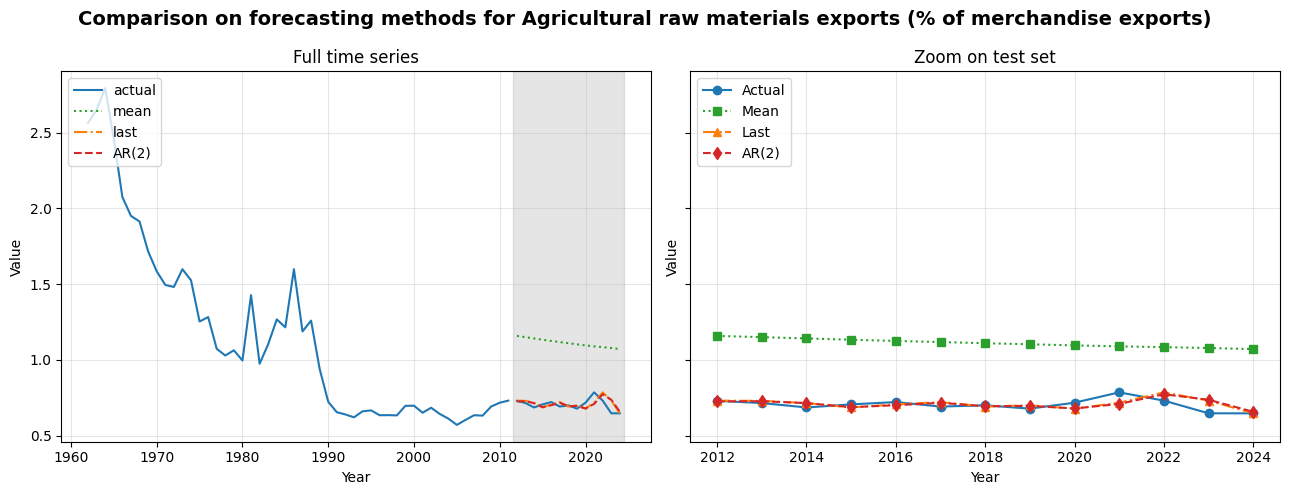


Indicator: Agricultural raw materials exports (% of merchandise exports)
    Year     Value  pred_mean  pred_last_value   pred_AR
50  2012  0.730070   1.158567         0.731385  0.726627
51  2013  0.715549   1.150165         0.730070  0.727549
52  2014  0.686465   1.141807         0.715549  0.715075
53  2015  0.706719   1.133216         0.686465  0.688271
54  2016  0.721962   1.125317         0.706719  0.701222
55  2017  0.692312   1.117984         0.721962  0.717207
56  2018  0.700483   1.110382         0.692312  0.694331
57  2019  0.678724   1.103191         0.700483  0.696915
58  2020  0.717790   1.095873         0.678724  0.679700
59  2021  0.786090   1.089465         0.717790  0.709635
60  2022  0.731626   1.084408         0.786090  0.773538
61  2023  0.647952   1.078625         0.731626  0.737455
62  2024  0.647641   1.071679         0.647952  0.658094
MAE -> mean: 0.407, last: 0.030, AR(2): 0.030
MSE -> mean: 0.168, last: 0.001, AR(2): 0.002


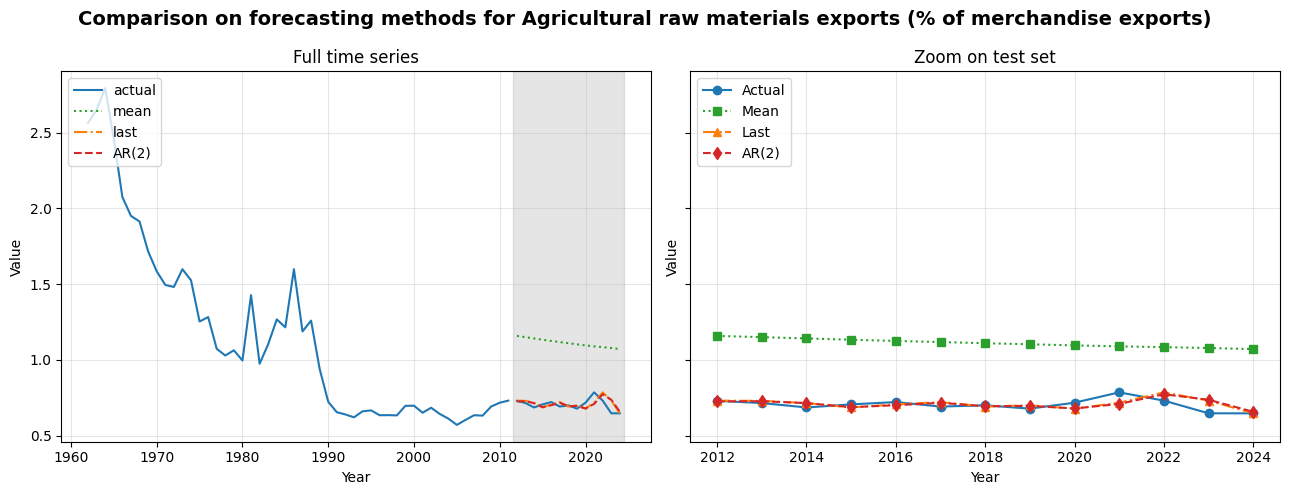


Indicator: Employment in agriculture (% of total employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  3.782819   5.010655         3.884447  3.954057
27  2018  3.756879   4.965180         3.782819  3.720160
28  2019  3.889869   4.922026         3.756879  3.736875
29  2020  3.981957   4.886435         3.889869  3.958505
30  2021  4.050170   4.856286         3.981957  4.028065
31  2022  3.787698   4.830282         4.050170  4.083128
32  2023  3.594572   4.797701         3.787698  3.637381
MAE -> mean: 1.061, last: 0.125, AR(2): 0.106
MSE -> mean: 1.148, last: 0.021, AR(2): 0.021


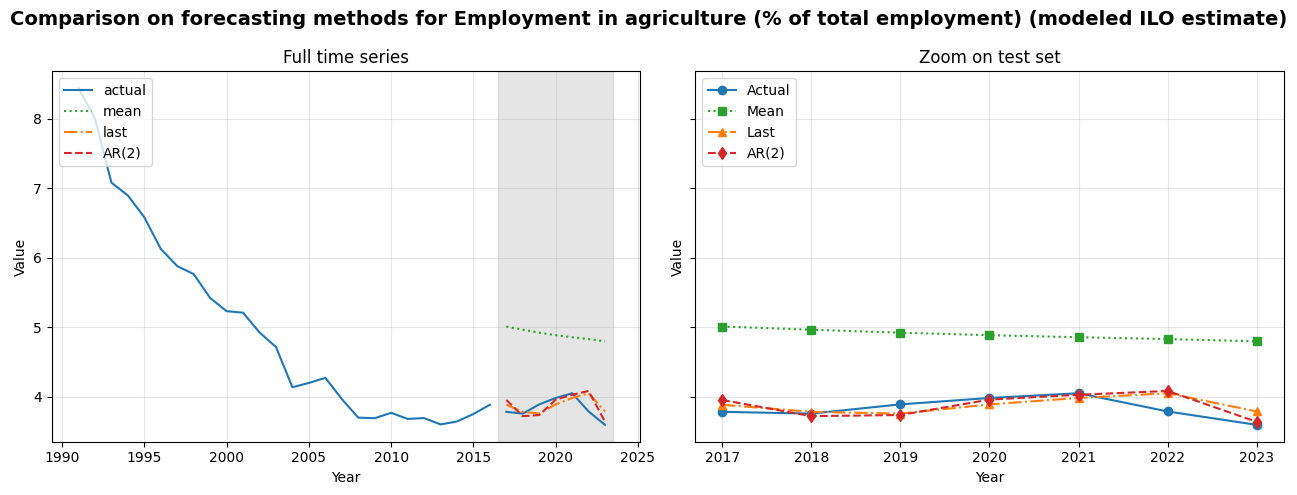


Indicator: Employment in agriculture, male (% of male employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  4.814398   5.510566         4.863903  4.956692
27  2018  4.739735   5.484782         4.814398  4.781853
28  2019  4.985230   5.458173         4.739735  4.693282
29  2020  5.106434   5.441864         4.985230  5.112632
30  2021  5.191661   5.430683         5.106434  5.166871
31  2022  4.840262   5.422973         5.191661  5.232994
32  2023  4.626057   5.404763         4.840262  4.651680
MAE -> mean: 0.550, last: 0.163, AR(2): 0.132
MSE -> mean: 0.340, last: 0.037, AR(2): 0.038


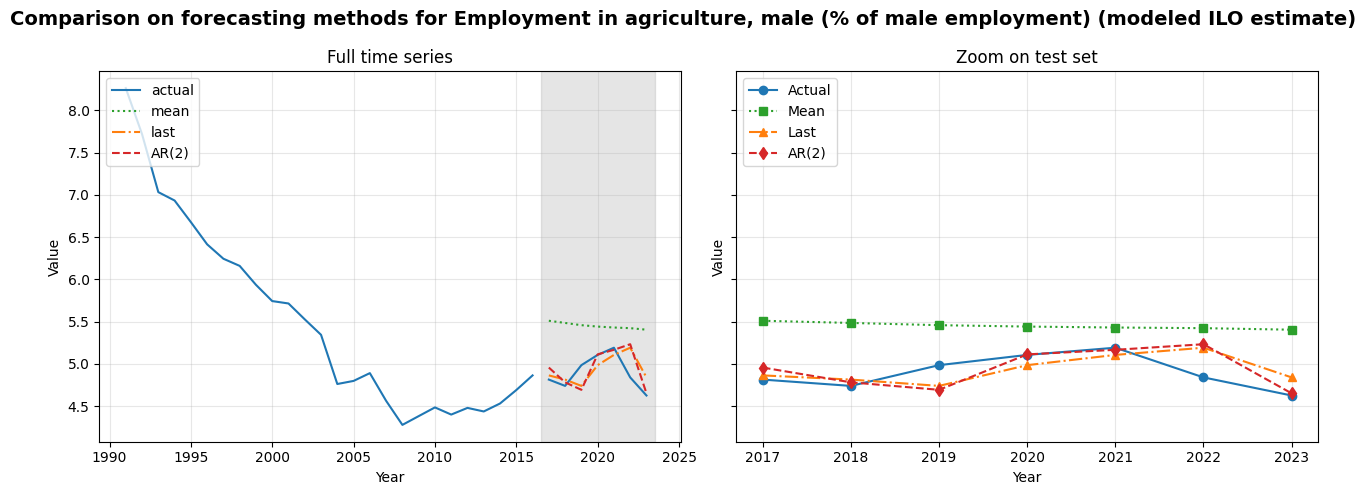


Indicator: Employment in agriculture, female (% of female employment) (modeled ILO estimate)
    Year     Value  pred_mean  pred_last_value   pred_AR
26  2017  2.350222   4.251096         2.517193  2.549459
27  2018  2.392978   4.180694         2.350222  2.260397
28  2019  2.378808   4.116847         2.392978  2.407329
29  2020  2.414602   4.056914         2.378808  2.365398
30  2021  2.468996   4.002170         2.414602  2.425931
31  2022  2.333656   3.952713         2.468996  2.489604
32  2023  2.182062   3.902118         2.333656  2.261231
MAE -> mean: 1.706, last: 0.086, AR(2): 0.098
MSE -> mean: 2.923, last: 0.011, AR(2): 0.013


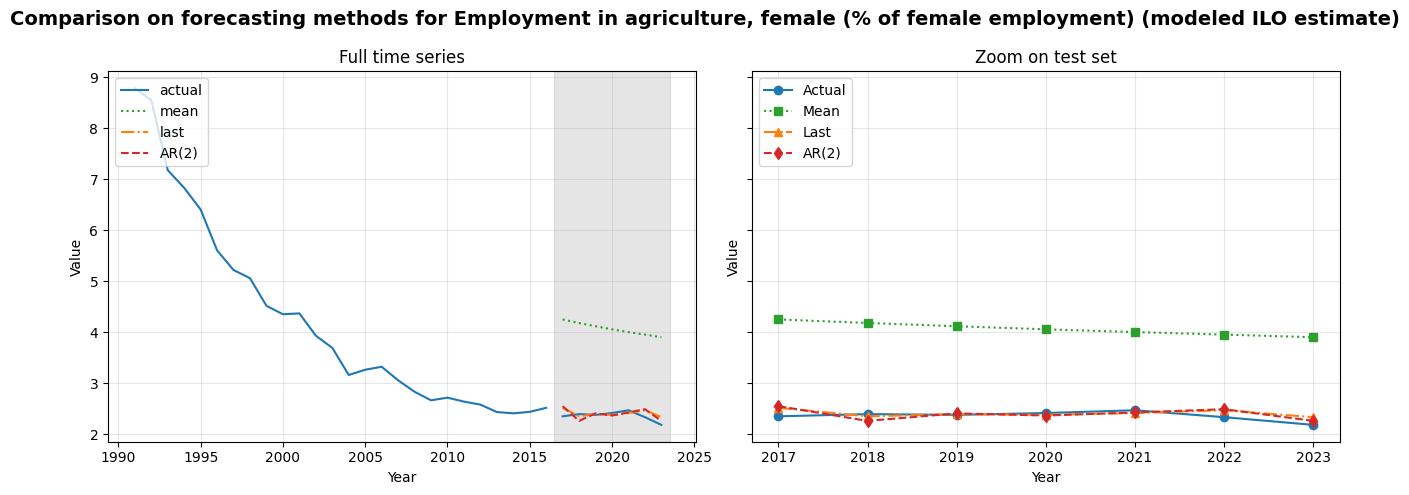


Indicator: Forest area (% of land area)
    Year      Value  pred_mean  pred_last_value    pred_AR
26  2016  31.620970  28.804963        31.439006  31.616087
27  2017  31.802934  28.909260        31.620970  31.798252
28  2018  31.984898  29.012605        31.802934  31.981688
29  2019  32.166970  29.115098        31.984898  32.162294
30  2020  32.348935  29.216827        32.166970  32.348766
31  2021  32.530899  29.317863        32.348935  32.523029
32  2022  32.712532  29.418271        32.530899  32.708557
MAE -> mean: 3.053, last: 0.182, AR(2): 0.004
MSE -> mean: 9.348, last: 0.033, AR(2): 0.000


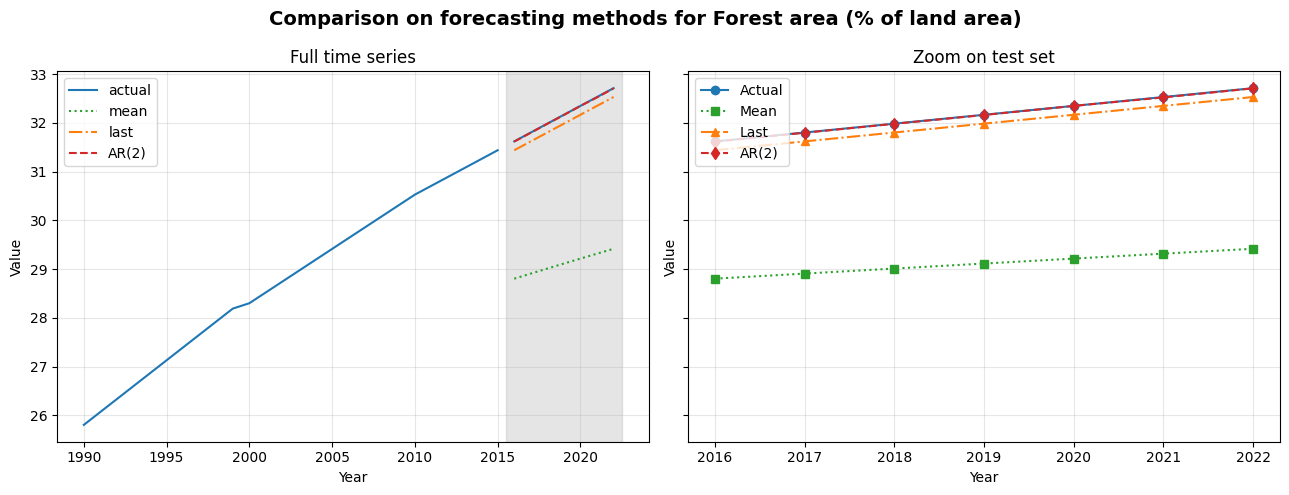

In [4]:
import warnings
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df["Value"][:i])
            pred_mean.extend([mean] * window)
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df["Value"][:i].iloc[-1]
            pred_last_value.extend([last_value] * window)
        return pred_last_value

    elif method == 'AR':
        pred_AR = []
        for i in range(train_len, total_len, window):
            # controllo: se non ci sono abbastanza osservazioni, salto
            if len(df["Value"][:i]) < 10:
                pred_AR.extend([np.nan] * window)
                continue
            try:
                model = SARIMAX(df["Value"][:i], order=(2,0,0))
                res = model.fit(disp=False)
                # print(f"AR params @ step {i}: {res.params}")
                predictions = res.get_prediction(start=i, end=i + window - 1)
                oos_pred = predictions.predicted_mean
                pred_AR.extend(oos_pred)
            except Exception as e:
                print(f"Errore AR per finestra {i}: {e}")
                pred_AR.extend([np.nan] * window)
        return pred_AR

indicators = ["Agricultural raw materials exports (% of merchandise exports)",
"Agricultural raw materials exports (% of merchandise exports)",
"Employment in agriculture (% of total employment) (modeled ILO estimate)",
"Employment in agriculture, male (% of male employment) (modeled ILO estimate)",
"Employment in agriculture, female (% of female employment) (modeled ILO estimate)",
"Forest area (% of land area)"]

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )
    
    train = df_temp[:int(0.8*len(df_temp))]
    test = df_temp[int(0.8*len(df_temp)):]
    
    TRAIN_LEN = len(train)
    HORIZON = len(test)

    pred_mean = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'mean')
    pred_last_value = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'last')
    pred_AR = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'AR')

    test = df_temp.iloc[TRAIN_LEN:TRAIN_LEN+HORIZON].copy()
    test['pred_mean'] = pred_mean[:HORIZON]
    test['pred_last_value'] = pred_last_value[:HORIZON]
    test['pred_AR'] = pred_AR[:HORIZON]
    print(test)
    
    # mae e mse a confronto
    mae_mean = mean_absolute_error(test['Value'], test['pred_mean'])
    mae_last = mean_absolute_error(test['Value'], test['pred_last_value'])
    mae_ar = mean_absolute_error(test['Value'], test['pred_AR'])

    mse_mean = mean_squared_error(test['Value'], test['pred_mean'])
    mse_last = mean_squared_error(test['Value'], test['pred_last_value'])
    mse_ar = mean_squared_error(test['Value'], test['pred_AR'])
    
    print(f"MAE -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
    print(f"MSE -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")
    
    # PLOT COMPARISON ON FORECASTING METHODS on stationary time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train['Year'], train['Value'])
    ax1.plot(test['Year'], test['Value'], color = colors[0], linestyle='-', label='actual')
    ax1.plot(test['Year'], test['pred_mean'], color = colors[1], linestyle=':', label='mean')
    ax1.plot(test['Year'], test['pred_last_value'], color = colors[2], linestyle='-.', label='last')
    ax1.plot(test['Year'], test['pred_AR'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Full time series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Value')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test['Year'], test['Value'], color = colors[0], linestyle='-', label='Actual', marker="o")
    ax2.plot(test['Year'], test['pred_mean'], color = colors[1], linestyle=':', label='Mean', marker="s")
    ax2.plot(test['Year'], test['pred_last_value'], color = colors[2], linestyle='-.', label='Last', marker="^")
    ax2.plot(test['Year'], test['pred_AR'], color = colors[3], linestyle='--', label='AR(2)', marker="d")
    ax2.legend(loc=2)
    ax2.set_title("Zoom on test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Value')
    ax2.grid(True, alpha=0.3)
    
    # ax.set_xticks(range(0, len(df_temp), 5)) 
    # ax.set_xticklabels(df_temp['Year'][::5])
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()


Indicator: Rural population (% of total population)
Original data - Train: 52, Test: 13
Diff data - Train: 51, Test: 13


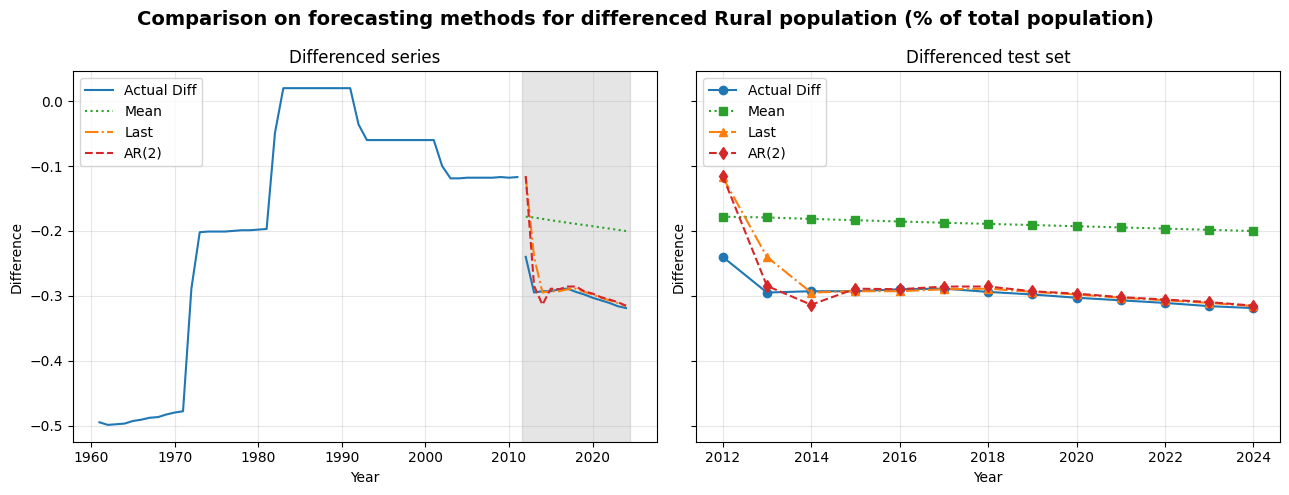

MAE livello originale -> mean: 0.719, last: 0.179, AR(2): 0.135
MSE livello originale -> mean: 0.683, last: 0.032, AR(2): 0.018


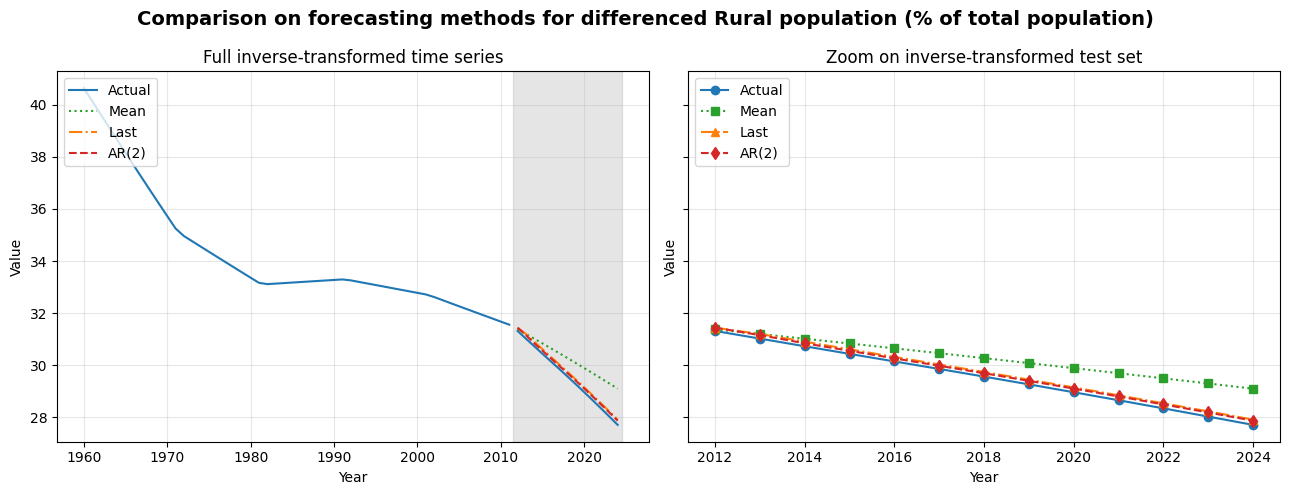


Indicator: Rural population
Original data - Train: 52, Test: 13
Diff data - Train: 51, Test: 13


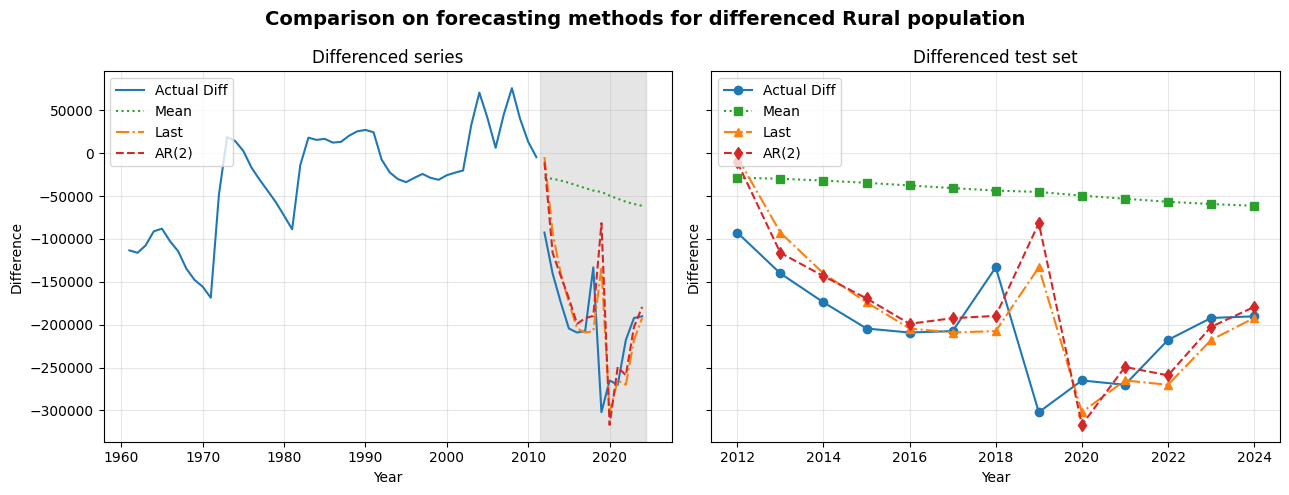

MAE livello originale -> mean: 1022047.961, last: 195332.308, AR(2): 220734.751
MSE livello originale -> mean: 1461795860902.569, last: 41265831409.231, AR(2): 56590421001.354


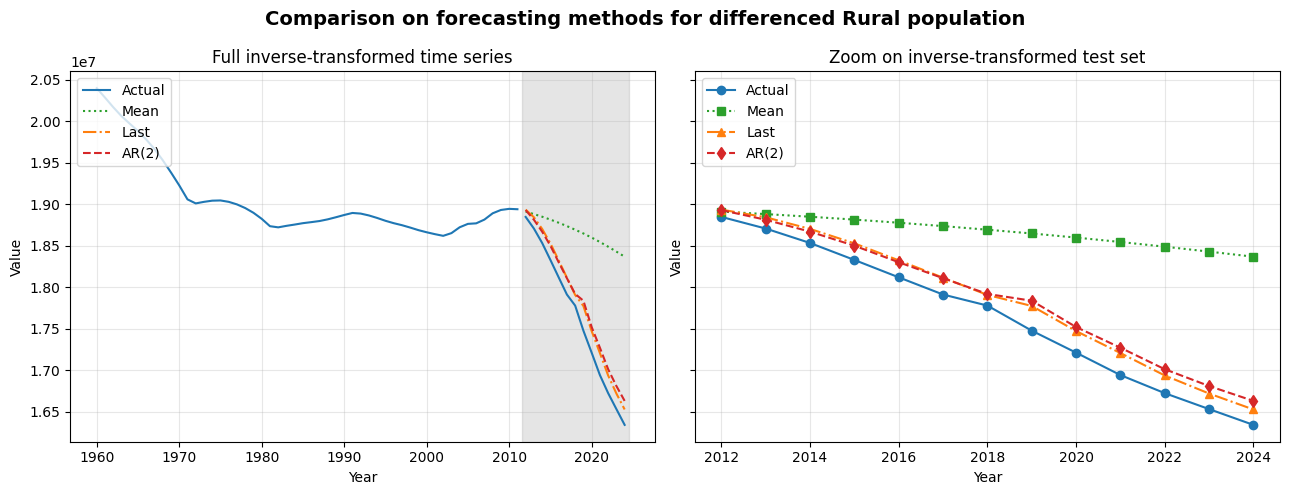


Indicator: Forest area (sq. km)
Original data - Train: 26, Test: 7
Diff data - Train: 25, Test: 7


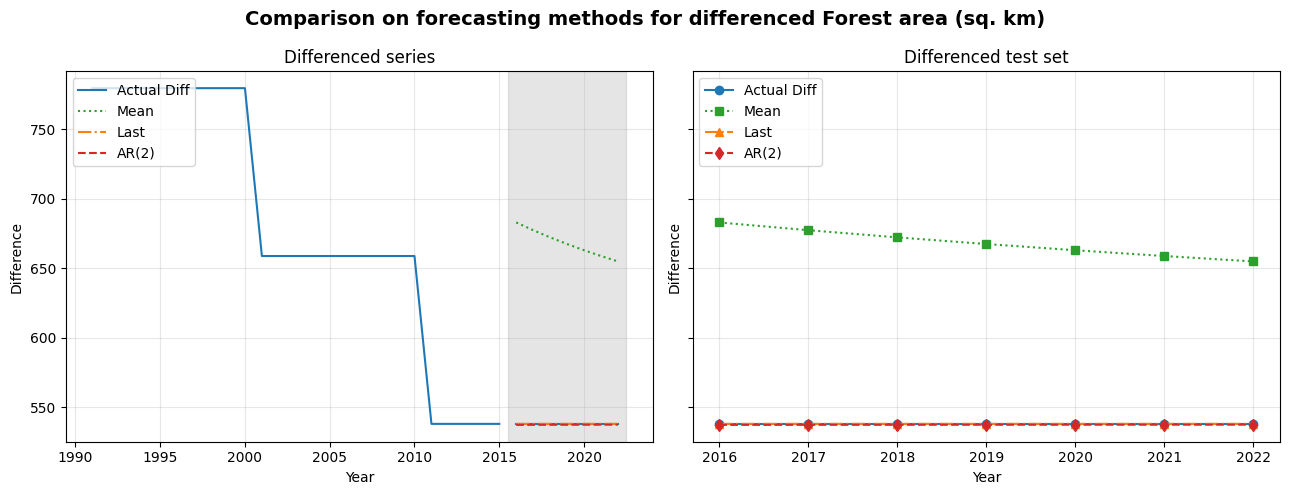

MAE livello originale -> mean: 538.560, last: 0.020, AR(2): 2.720
MSE livello originale -> mean: 355029.962, last: 0.000, AR(2): 9.027


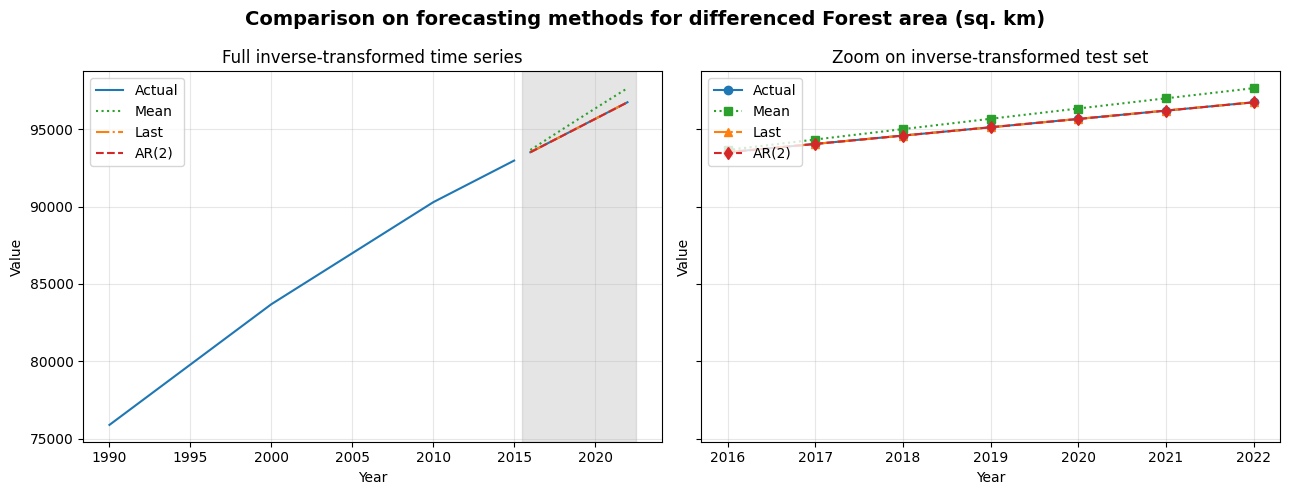

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df["Diff"][:i].values)
            pred_mean.extend([mean] * window)
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df["Diff"][:i].iloc[-1]
            pred_last_value.extend([last_value] * window)
        return pred_last_value

    elif method == 'AR':
        pred_AR = []
        for i in range(train_len, total_len, window):
            # controllo: se non ci sono abbastanza osservazioni, salto
            if len(df["Diff"][:i]) < 12:
                pred_AR.extend([np.nan] * window)
                continue
            try:
                model = SARIMAX(df["Diff"][:i].values, order=(2,0,0))
                res = model.fit(disp=False)
                # print(f"AR params @ step {i}: {res.params}")
                predictions = res.get_prediction(start=i, end=i + window - 1)
                oos_pred = predictions.predicted_mean
                pred_AR.extend(oos_pred)
            except Exception as e:
                print(f"Errore AR per finestra {i}: {e}")
                pred_AR.extend([np.nan] * window)
        return pred_AR

indicators = ["Rural population (% of total population)",
"Rural population",
"Forest area (sq. km)"]

for indicator in indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {indicator}")

    df_temp = (
        df[df["Indicator Name"] == indicator]
        .melt(id_vars=["Indicator Name"], var_name="Year", value_name="Value")
        .assign(Year=lambda d: d["Year"].astype(int))
        .dropna(subset=["Value"])
        [["Year", "Value"]]
        .reset_index(drop=True)
    )

    split_idx = int(0.8*len(df_temp))
    train_original = df_temp.iloc[:split_idx]
    test_original = df_temp.iloc[split_idx:]
    last_train_value = train_original['Value'].iloc[-1]

    df_temp['Diff'] = df_temp['Value'].diff()
    df_temp = df_temp.dropna(subset=['Diff']).reset_index(drop=True)
    # Dopo differenziazione, gli indici cambiano
    # Il train ora va da 0 a split_idx-2 (perché perdiamo il primo elemento per diff)
    train_len_diff = split_idx - 1
    train = df_temp.iloc[:train_len_diff]
    test = df_temp.iloc[train_len_diff:]

    TRAIN_LEN = len(train)
    HORIZON = len(test)

    print(f"Original data - Train: {len(train_original)}, Test: {len(test_original)}")
    print(f"Diff data - Train: {TRAIN_LEN}, Test: {HORIZON}")

    pred_mean = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'mean')
    pred_last_value = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'last')
    pred_AR = rolling_forecast(df_temp, TRAIN_LEN, HORIZON, 1, 'AR')

    test_results = test.copy()
    test_results['pred_mean'] = pred_mean[:HORIZON]
    test_results['pred_last_value'] = pred_last_value[:HORIZON]
    test_results['pred_AR'] = pred_AR[:HORIZON]
    
    # Inverse transformation per tornare ai livelli originali
    test_results['pred_mean_levels'] = last_train_value + np.cumsum(test_results['pred_mean'])
    test_results['pred_last_value_levels'] = last_train_value + np.cumsum(test_results['pred_last_value'])
    test_results['pred_AR_levels'] = last_train_value + np.cumsum(test_results['pred_AR'])
    
    # Allinea con i valori originali del test set
    # I valori originali del test set iniziano da split_idx
    test_actual_values = test_original['Value'].values
    
    # test = df_temp.iloc[TRAIN_LEN:TRAIN_LEN+HORIZON].copy()
    # test['pred_mean'] = pred_mean[:HORIZON]
    # test['pred_last_value'] = pred_last_value[:HORIZON]
    # test['pred_AR'] = pred_AR[:HORIZON]
    # print(test)
    
    # PLOT COMPARISON ON FORECASTING METHODS on differenced time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for differenced {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train['Year'], train['Diff'])
    ax1.plot(test_results['Year'], test_results['Diff'], color = colors[0], linestyle='-', label='Actual Diff')
    ax1.plot(test_results['Year'], test_results['pred_mean'], color = colors[1], linestyle=':', label='Mean')
    ax1.plot(test_results['Year'], test_results['pred_last_value'], color = colors[2], linestyle='-.', label='Last')
    ax1.plot(test_results['Year'], test_results['pred_AR'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Differenced series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Difference')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test_results['Year'], test_results['Diff'], color = colors[0], linestyle='-', label='Actual Diff', marker='o')
    ax2.plot(test_results['Year'], test_results['pred_mean'], color = colors[1], linestyle=':', label='Mean', marker='s')
    ax2.plot(test_results['Year'], test_results['pred_last_value'], color = colors[2], linestyle='-.', label='Last', marker='^')
    ax2.plot(test_results['Year'], test_results['pred_AR'], color = colors[3], linestyle='--', label='AR(2)', marker='d')
    ax2.legend(loc=2)
    ax2.set_title("Differenced test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Difference')
    ax2.grid(True, alpha=0.3)
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()

    valid_idx = ~np.isnan(test_results['pred_AR_levels'])
    if np.sum(valid_idx) > 0:
        test_valid = test_results[valid_idx]
        actual_values_valid = test_actual_values[valid_idx]
        
        mae_mean = mean_absolute_error(actual_values_valid, test_valid['pred_mean_levels'])
        mae_last = mean_absolute_error(actual_values_valid, test_valid['pred_last_value_levels'])
        mae_ar = mean_absolute_error(actual_values_valid, test_valid['pred_AR_levels'])

        mse_mean = mean_squared_error(actual_values_valid, test_valid['pred_mean_levels'])
        mse_last = mean_squared_error(actual_values_valid, test_valid['pred_last_value_levels'])
        mse_ar = mean_squared_error(actual_values_valid, test_valid['pred_AR_levels'])
        
        print(f"MAE livello originale -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
        print(f"MSE livello originale -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")

    # test['pred_mean_levels'] = np.cumsum(test['pred_mean']) + last_train_value
    # test['pred_last_value_levels'] = np.cumsum(test['pred_last_value']) + last_train_value
    # test['pred_AR_levels'] = np.cumsum(test['pred_AR']) + last_train_value
    
    # # mae e mse a confronto
    # mae_mean = mean_absolute_error(test['Value'], test['pred_mean_levels'])
    # mae_last = mean_absolute_error(test['Value'], test['pred_last_value_levels'])
    # mae_ar = mean_absolute_error(test['Value'], test['pred_AR_levels'])

    # mse_mean = mean_squared_error(test['Value'], test['pred_mean_levels'])
    # mse_last = mean_squared_error(test['Value'], test['pred_last_value_levels'])
    # mse_ar = mean_squared_error(test['Value'], test['pred_AR_levels'])
    
    # print(f"MAE livello originale -> mean: {mae_mean:.3f}, last: {mae_last:.3f}, AR(2): {mae_ar:.3f}")
    # print(f"MSE livello originale -> mean: {mse_mean:.3f}, last: {mse_last:.3f}, AR(2): {mse_ar:.3f}")
    
    # PLOT COMPARISON ON FORECASTING METHODS on inverse-trasnformed time series
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(13,5))
    fig.suptitle(f"Comparison on forecasting methods for differenced {indicator}", fontsize=14, fontweight="bold")
    ax1.plot(train_original['Year'], train_original['Value'])
    ax1.plot(test_original['Year'], test_original['Value'], color = colors[0], linestyle='-', label='Actual')
    ax1.plot(test_valid['Year'], test_valid['pred_mean_levels'], color = colors[1], linestyle=':', label='Mean')
    ax1.plot(test_valid['Year'], test_valid['pred_last_value_levels'], color = colors[2], linestyle='-.', label='Last')
    ax1.plot(test_valid['Year'], test_valid['pred_AR_levels'], color = colors[3], linestyle='--', label='AR(2)')
    ax1.legend(loc=2)
    ax1.set_title("Full inverse-transformed time series")
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Value')
    ax1.grid(True, alpha=0.3)
    start_year = int(test['Year'].iloc[0])
    end_year = int(test['Year'].iloc[-1])
    ax1.axvspan(start_year - 0.5, end_year + 0.5, color='#808080', alpha=0.2)
    
    ax2.plot(test_original['Year'], test_original['Value'], color = colors[0], linestyle='-', label='Actual', marker='o')
    ax2.plot(test_valid['Year'], test_valid['pred_mean_levels'], color = colors[1], linestyle=':', label='Mean', marker='s')
    ax2.plot(test_valid['Year'], test_valid['pred_last_value_levels'], color = colors[2], linestyle='-.', label='Last', marker='^')
    ax2.plot(test_valid['Year'], test_valid['pred_AR_levels'], color = colors[3], linestyle='--', label='AR(2)', marker='d')
    ax2.legend(loc=2)
    ax2.set_title("Zoom on inverse-transformed test set")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Value')
    ax2.grid(True, alpha=0.3)
    
    ax1.tick_params(labelbottom=True)
    ax2.tick_params(labelbottom=True) 
    plt.setp(ax2.get_xticklabels(), visible=True)
    plt.tight_layout()
    plt.show()